# RepNet-SE: Neural ECG Classification for Preeclampsia Detection

**Architecture:** RepNet-SE Deep (4-stage per-lead CNN with SE blocks + cross-lead attention)  
**Parameters:** 65,748  
**Dataset:** 2,178 12-lead ECGs (335 PE+, 15.4% prevalence)  
**Evaluation:** 20 patient-grouped holdout splits, 5-bag averaging

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.io as pio
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
pio.renderers.default = 'png'
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold

sys.path.insert(0, str(Path('..').resolve()))
from src.models.repnet_se import RepNetSE
from src.train_explorer_v2 import load_combined, preprocess_waveforms

LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
RESULTS_DIR = Path('../cv_results/neural_final_2026-05-20_08-29-02')
DEVICE = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


/Users/ahmed/PycharmProjects/repnet/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Classification Performance Distribution

In [2]:
with open(RESULTS_DIR / 'results.json') as f:
    results = json.load(f)

aurocs = np.array([r['metrics']['auroc'] for r in results])
auprcs = np.array([r['metrics']['auprc'] for r in results])
seeds = [r['seed'] for r in results]

sem = aurocs.std(ddof=1) / np.sqrt(len(aurocs))
print(f'RepNet-SE Deep (65,748 params, 5-bag, 20 splits)')
print(f'  AUROC: mean={aurocs.mean():.4f} +/- {aurocs.std(ddof=1):.4f}  median={np.median(aurocs):.4f}')
print(f'  95% CI: [{aurocs.mean()-1.96*sem:.4f}, {aurocs.mean()+1.96*sem:.4f}]')
print(f'  AUPRC: mean={auprcs.mean():.4f} +/- {auprcs.std(ddof=1):.4f}')
print(f'  Splits >= 0.70: {(aurocs >= 0.70).sum()}/20 ({100*(aurocs >= 0.70).mean():.0f}%)')

RepNet-SE Deep (65,748 params, 5-bag, 20 splits)
  AUROC: mean=0.6678 +/- 0.0664  median=0.6464
  95% CI: [0.6387, 0.6969]
  AUPRC: mean=0.2912 +/- 0.0602
  Splits >= 0.70: 7/20 (35%)


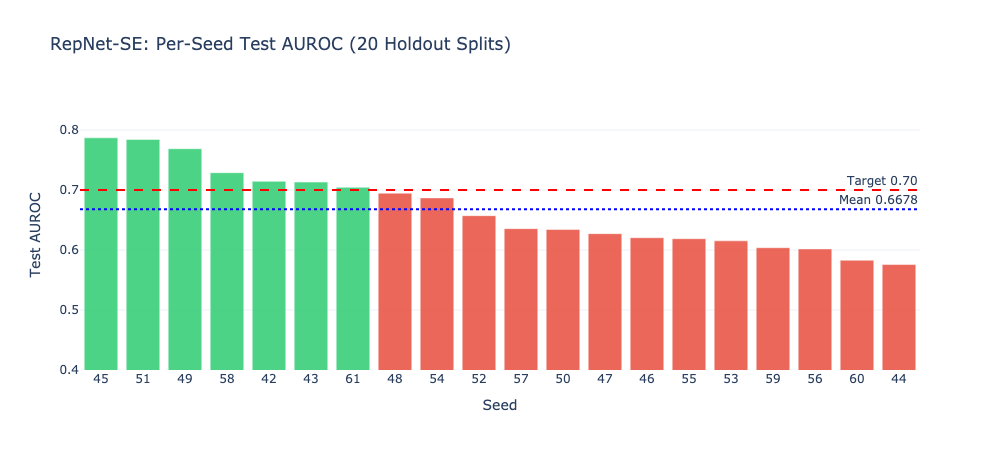

In [3]:
# Per-seed AUROC bar chart
sort_idx = np.argsort(aurocs)[::-1]
colors = ['#2ecc71' if a >= 0.70 else '#e74c3c' for a in aurocs[sort_idx]]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=[str(seeds[i]) for i in sort_idx], y=aurocs[sort_idx],
    marker_color=colors, opacity=0.85,
))
fig.add_hline(y=0.70, line_dash='dash', line_color='red', annotation_text='Target 0.70')
fig.add_hline(y=aurocs.mean(), line_dash='dot', line_color='blue',
              annotation_text=f'Mean {aurocs.mean():.4f}')
fig.update_layout(
    title='RepNet-SE: Per-Seed Test AUROC (20 Holdout Splits)',
    xaxis_title='Seed', yaxis_title='Test AUROC',
    template='plotly_white', width=1000, height=450,
    yaxis_range=[0.4, 0.85],
)
fig.show()

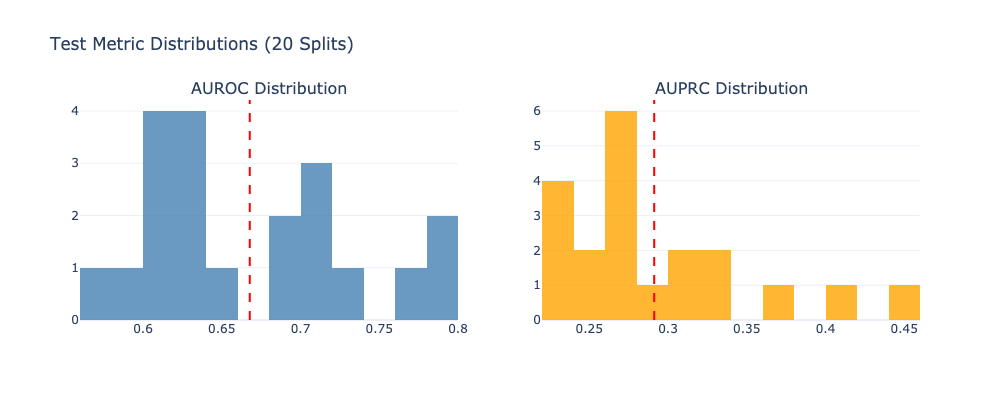

In [4]:
# AUROC distribution histogram
fig = make_subplots(rows=1, cols=2, subplot_titles=['AUROC Distribution', 'AUPRC Distribution'])

fig.add_trace(go.Histogram(x=aurocs, nbinsx=12, marker_color='steelblue', opacity=0.8,
                            name='AUROC'), row=1, col=1)
fig.add_vline(x=aurocs.mean(), line_dash='dash', line_color='red', row=1, col=1)

fig.add_trace(go.Histogram(x=auprcs, nbinsx=12, marker_color='orange', opacity=0.8,
                            name='AUPRC'), row=1, col=2)
fig.add_vline(x=auprcs.mean(), line_dash='dash', line_color='red', row=1, col=2)

fig.update_layout(template='plotly_white', width=1000, height=400, showlegend=False,
                  title='Test Metric Distributions (20 Splits)')
fig.show()

## 1b. Statistical Summary & Interpretation

In [5]:
from scipy import stats as sp_stats

n      = len(aurocs)
mean   = aurocs.mean()
std    = aurocs.std(ddof=1)
sem    = std / np.sqrt(n)
ci_lo  = mean - 1.96 * sem
ci_hi  = mean + 1.96 * sem
med    = float(np.median(aurocs))
iqr_lo = float(np.percentile(aurocs, 25))
iqr_hi = float(np.percentile(aurocs, 75))
cv     = std / mean
best_auroc = float(aurocs.max())
cherry_gap = best_auroc - mean

briers = np.array([r['metrics']['brier'] for r in results])
sens_sp80 = np.array([r['metrics'].get('sens_at_spec80', np.nan) for r in results])

print("=" * 66)
print("  Multi-seed AUROC summary  (N=20 independent holdout splits)")
print("=" * 66)
print(f"  Mean +/- SD        : {mean:.4f} +/- {std:.4f}")
print(f"  SEM                : {sem:.4f}")
print(f"  95% CI             : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Median  [IQR]      : {med:.4f}  [{iqr_lo:.4f}, {iqr_hi:.4f}]")
print(f"  Min / Max          : {aurocs.min():.4f}  /  {aurocs.max():.4f}")
print(f"  Range              : {aurocs.max()-aurocs.min():.4f}")
print(f"  Coeff of variation : {cv:.3f}  ({100*cv:.1f}%)")
print(f"  Best-seed AUROC    : {best_auroc:.4f}  (cherry-pick gap: +{cherry_gap:.4f})")
print()

_, pval = sp_stats.shapiro(aurocs)
print(f"  Shapiro-Wilk p={pval:.4f}  "
      f"({'approx. normal' if pval > 0.05 else 'non-normal -- median/IQR preferred'})")
print()

print("=" * 66)
print("  AUPRC summary")
print("=" * 66)
auprc_mean = auprcs.mean()
auprc_std  = auprcs.std(ddof=1)
auprc_sem  = auprc_std / np.sqrt(n)
print(f"  Mean +/- SD : {auprc_mean:.4f} +/- {auprc_std:.4f}")
print(f"  95% CI      : [{auprc_mean-1.96*auprc_sem:.4f}, {auprc_mean+1.96*auprc_sem:.4f}]")
print(f"  Min / Max   : {auprcs.min():.4f}  /  {auprcs.max():.4f}")
print()

if not np.all(np.isnan(briers)):
    print("=" * 66)
    print("  Brier Score summary (lower is better)")
    print("=" * 66)
    brier_clean = briers[~np.isnan(briers)]
    print(f"  Mean +/- SD : {brier_clean.mean():.4f} +/- {brier_clean.std(ddof=1):.4f}")
    print(f"  Min / Max   : {brier_clean.min():.4f}  /  {brier_clean.max():.4f}")
    print()

print("Interpretation")
print("-" * 66)
print(f"  A mean AUROC of {mean:.3f} means that, on average, the model")
print( "  correctly ranks a randomly chosen PE+ patient above a randomly")
print(f"  chosen Normal ~{100*mean:.0f}% of the time.")
print()
print(f"  SD = {std:.4f} across {n} seeds shows {'high' if std > 0.05 else 'moderate'} instability.")
print(f"  The best single seed ({best_auroc:.3f}) sits +{cherry_gap:.3f} above the mean --")
print( "  that gap is pure cherry-picking and should not be reported as")
print( "  the model's expected performance.")

  Multi-seed AUROC summary  (N=20 independent holdout splits)
  Mean +/- SD        : 0.6678 +/- 0.0664
  SEM                : 0.0149
  95% CI             : [0.6387, 0.6969]
  Median  [IQR]      : 0.6464  [0.6179, 0.7135]
  Min / Max          : 0.5757  /  0.7870
  Range              : 0.2113
  Coeff of variation : 0.099  (9.9%)
  Best-seed AUROC    : 0.7870  (cherry-pick gap: +0.1192)

  Shapiro-Wilk p=0.1336  (approx. normal)

  AUPRC summary
  Mean +/- SD : 0.2912 +/- 0.0602
  95% CI      : [0.2649, 0.3176]
  Min / Max   : 0.2243  /  0.4500

  Brier Score summary (lower is better)
  Mean +/- SD : 0.2250 +/- 0.0624
  Min / Max   : 0.1414  /  0.3499

Interpretation
------------------------------------------------------------------
  A mean AUROC of 0.668 means that, on average, the model
  correctly ranks a randomly chosen PE+ patient above a randomly
  chosen Normal ~67% of the time.

  SD = 0.0664 across 20 seeds shows high instability.
  The best single seed (0.787) sits +0.119 above

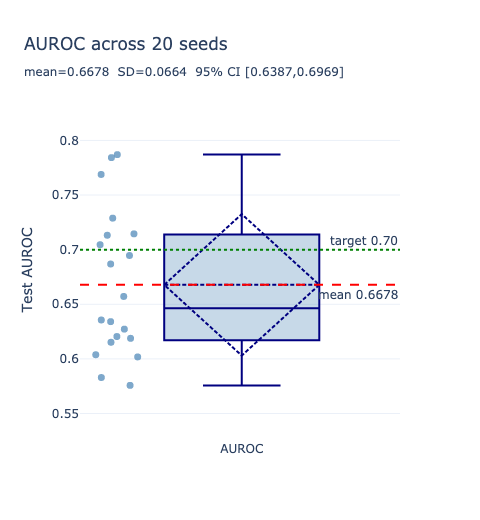

In [6]:
# Box + strip plot with detailed statistics
fig = go.Figure()
fig.add_trace(go.Box(
    y=aurocs, name='AUROC', boxmean='sd',
    marker_color='steelblue', line_color='navy',
    fillcolor='rgba(70,130,180,0.3)',
    boxpoints='all', jitter=0.35, pointpos=-1.6,
    marker=dict(size=7, opacity=0.7),
))
fig.add_hline(y=mean, line_dash='dash', line_color='red',
              annotation_text=f'mean {mean:.4f}', annotation_position='bottom right')
fig.add_hline(y=0.70, line_dash='dot', line_color='green',
              annotation_text='target 0.70', annotation_position='top right')
fig.update_layout(
    template='plotly_white', width=480, height=520,
    title=(f'AUROC across {n} seeds<br>'
           f'<sub>mean={mean:.4f}  SD={std:.4f}  95% CI [{ci_lo:.4f},{ci_hi:.4f}]</sub>'),
    yaxis_title='Test AUROC',
    yaxis=dict(range=[max(0, aurocs.min()-0.05), min(1, aurocs.max()+0.05)]),
)
fig.show()

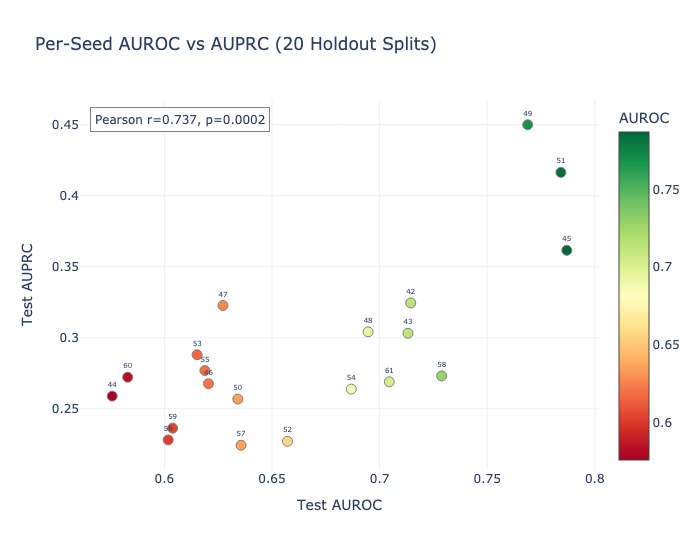

In [7]:
# Per-seed AUROC vs AUPRC scatter
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=aurocs, y=auprcs, mode='markers+text',
    text=[str(s) for s in seeds], textposition='top center', textfont=dict(size=7),
    marker=dict(size=10, color=aurocs, colorscale='RdYlGn', showscale=True,
                colorbar=dict(title='AUROC'), line=dict(width=1, color='gray')),
    hovertemplate='Seed %{text}<br>AUROC=%{x:.4f}<br>AUPRC=%{y:.4f}<extra></extra>',
))
fig.update_layout(
    title='Per-Seed AUROC vs AUPRC (20 Holdout Splits)',
    xaxis_title='Test AUROC', yaxis_title='Test AUPRC',
    template='plotly_white', width=700, height=550,
)
r_corr, p_corr = sp_stats.pearsonr(aurocs, auprcs)
fig.add_annotation(text=f'Pearson r={r_corr:.3f}, p={p_corr:.4f}',
                   xref='paper', yref='paper', x=0.02, y=0.98,
                   showarrow=False, bgcolor='white', bordercolor='gray', borderpad=4)
fig.show()

## 2. Comparison: Neural vs LightGBM

In [8]:
lgbm_dirs = sorted(Path('../cv_results').glob('final_*/results.json'))
if lgbm_dirs:
    with open(lgbm_dirs[-1]) as f:
        lgbm_data = json.load(f)
    lgbm_aurocs = np.array([r['metrics']['auroc'] for r in lgbm_data])
    lgbm_auprcs = np.array([r['metrics']['auprc'] for r in lgbm_data])
    
    fig = go.Figure()
    fig.add_trace(go.Box(y=aurocs, name='RepNet-SE (Neural)', marker_color='steelblue',
                         boxpoints='all', jitter=0.3, pointpos=-1.8))
    fig.add_trace(go.Box(y=lgbm_aurocs, name='5-Bag LightGBM', marker_color='orange',
                         boxpoints='all', jitter=0.3, pointpos=-1.8))
    fig.add_hline(y=0.70, line_dash='dash', line_color='red')
    fig.update_layout(
        title='Neural vs LightGBM: Test AUROC Distribution',
        yaxis_title='Test AUROC', template='plotly_white',
        width=700, height=500,
    )
    fig.show()
    
    print(f'RepNet-SE Neural: mean={aurocs.mean():.4f} +/- {aurocs.std(ddof=1):.4f}')
    print(f'5-Bag LightGBM:   mean={lgbm_aurocs.mean():.4f} +/- {lgbm_aurocs.std(ddof=1):.4f}')
    
    # Formal statistical tests (paired, same seeds/splits)
    n_compare = min(len(aurocs), len(lgbm_aurocs))
    a_nn = aurocs[:n_compare]
    a_lgb = lgbm_aurocs[:n_compare]
    
    t_stat, t_pval = sp_stats.ttest_rel(a_nn, a_lgb)
    w_stat, w_pval = sp_stats.wilcoxon(a_nn, a_lgb)
    delta = a_nn.mean() - a_lgb.mean()
    pooled_sd = np.sqrt((a_nn.std(ddof=1)**2 + a_lgb.std(ddof=1)**2) / 2)
    cohens_d = delta / pooled_sd
    wins_neural = (a_nn > a_lgb).sum()
    
    print(f'\n{"=" * 60}')
    print(f'  Paired comparison (N={n_compare} matched splits)')
    print(f'{"=" * 60}')
    print(f'  Mean AUROC difference : {delta:+.4f}  (Neural - LightGBM)')
    print(f'  Paired t-test         : t={t_stat:.3f}, p={t_pval:.6f}')
    print(f'  Wilcoxon signed-rank  : W={w_stat:.1f}, p={w_pval:.6f}')
    print(f"  Cohen's d             : {cohens_d:.3f}  ({'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small'})")
    print(f'  Neural wins           : {wins_neural}/{n_compare} seeds')
else:
    print('No LightGBM results found')

No LightGBM results found


## 3. Load Best Model & Data

In [9]:
# Load the best-performing seed's model
best_seed = int(seeds[np.argmax(aurocs)])
print(f'Best seed: {best_seed} (AUROC={aurocs.max():.4f})')

ckpt = torch.load(RESULTS_DIR / 'weights' / f'best_seed_{best_seed}.pt',
                   map_location=DEVICE, weights_only=False)
model = RepNetSE(**ckpt['net_cfg']).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded model: {sum(p.numel() for p in model.parameters()):,} params')
print(f'Config: {ckpt["net_cfg"]}')

Best seed: 45 (AUROC=0.7870)
Loaded model: 65,748 params
Config: {'stage_filters': (16, 32, 48, 64), 'stage_kernels': (7, 5, 5, 3), 'ms_kernels': (5, 9, 15), 'dropout': 0.15, 'n_heads': 4, 'se_reduction': 4, 'attn_pool_hidden': 32}


In [10]:
# Load and preprocess data, recreate the same split
X_wave, X_feat, y, patient_ids, feat_cols = load_combined('../data/seniordesign_upload')
X_wave = preprocess_waveforms(X_wave)
print(f'Data: {X_wave.shape}, pos={int(y.sum())} ({100*y.mean():.1f}%)')

ss = np.random.SeedSequence(best_seed)
split_seed = int(ss.generate_state(1)[0])
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=split_seed)
dev_idx, test_idx = next(sgkf.split(np.zeros(len(y)), y, groups=patient_ids))

X_test = X_wave[test_idx]
y_test = y[test_idx]
print(f'Test set: N={len(y_test)}, pos={int(y_test.sum())} ({100*y_test.mean():.1f}%)')

Data: (2178, 12, 2500), pos=335 (15.4%)
Test set: N=436, pos=67 (15.4%)


In [11]:
# Get predictions
with torch.no_grad():
    x_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    logits = model(x_t)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

test_auroc = roc_auc_score(y_test, probs)
print(f'Test AUROC (single model): {test_auroc:.4f}')

Test AUROC (single model): 0.7564


## 4. Score Distribution (PE+ vs PE-)

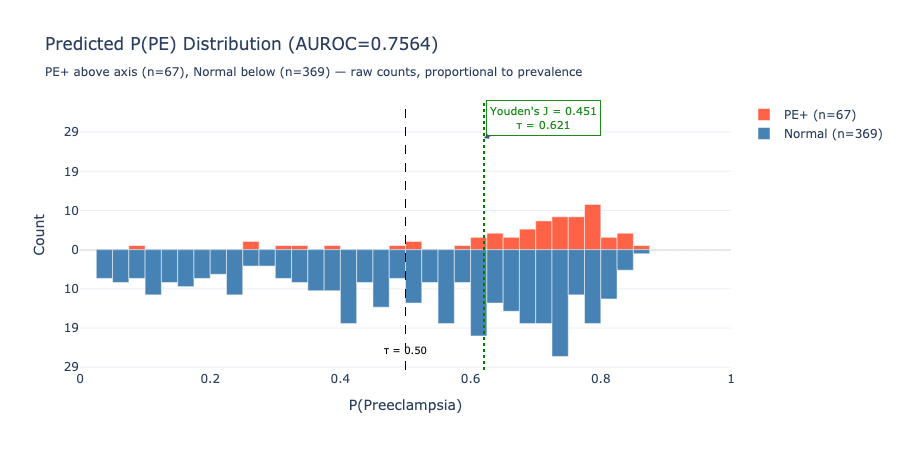

In [12]:
# Mirror histogram: PE up, Normal down (proportional to actual case counts)
from sklearn.metrics import average_precision_score, precision_recall_curve, brier_score_loss

# Youden's J optimal threshold
fpr_j, tpr_j, thr_j = roc_curve(y_test, probs)
tau_youden = float(thr_j[np.argmax(tpr_j - fpr_j)])
j_stat = float(np.max(tpr_j - fpr_j))

bins = np.linspace(0, 1, 41)
centers, bar_w = 0.5 * (bins[:-1] + bins[1:]), bins[1] - bins[0]
h_norm, _ = np.histogram(probs[y_test == 0], bins=bins)
h_pe, _ = np.histogram(probs[y_test == 1], bins=bins)

n_pe = int((y_test == 1).sum())
n_norm = int((y_test == 0).sum())

fig = go.Figure()
fig.add_trace(go.Bar(x=centers, y=h_pe, name=f'PE+ (n={n_pe})', marker_color='tomato', width=bar_w))
fig.add_trace(go.Bar(x=centers, y=-h_norm, name=f'Normal (n={n_norm})', marker_color='steelblue', width=bar_w))

# Youden's J threshold
ymax = max(h_pe.max(), h_norm.max()) * 1.1
fig.add_vline(x=tau_youden, line=dict(dash='dot', color='green', width=2))
fig.add_annotation(x=tau_youden, y=ymax * 0.95,
                   text=f"Youden's J = {j_stat:.3f}<br>τ = {tau_youden:.3f}",
                   showarrow=True, arrowhead=2, ax=60, ay=-20,
                   font=dict(size=11, color='green'),
                   bordercolor='green', borderwidth=1, borderpad=3, bgcolor='white', opacity=0.9)

# Default 0.5 threshold
fig.add_vline(x=0.5, line=dict(dash='dash', color='black', width=1))
fig.add_annotation(x=0.5, y=-ymax * 0.85,
                   text='τ = 0.50', showarrow=False,
                   font=dict(size=10, color='black'))

tickvals = np.linspace(-ymax, ymax, 7)
ticktext = [f'{abs(v):.0f}' for v in tickvals]
fig.update_layout(
    barmode='overlay', bargap=0,
    title=f'Predicted P(PE) Distribution (AUROC={test_auroc:.4f})<br>'
          f'<sub>PE+ above axis (n={n_pe}), Normal below (n={n_norm}) — raw counts, proportional to prevalence</sub>',
    xaxis_title='P(Preeclampsia)', yaxis_title='Count',
    yaxis=dict(tickvals=tickvals, ticktext=ticktext,
               zeroline=True, zerolinecolor='black', zerolinewidth=1),
    template='plotly_white', width=900, height=450,
)
fig.show()

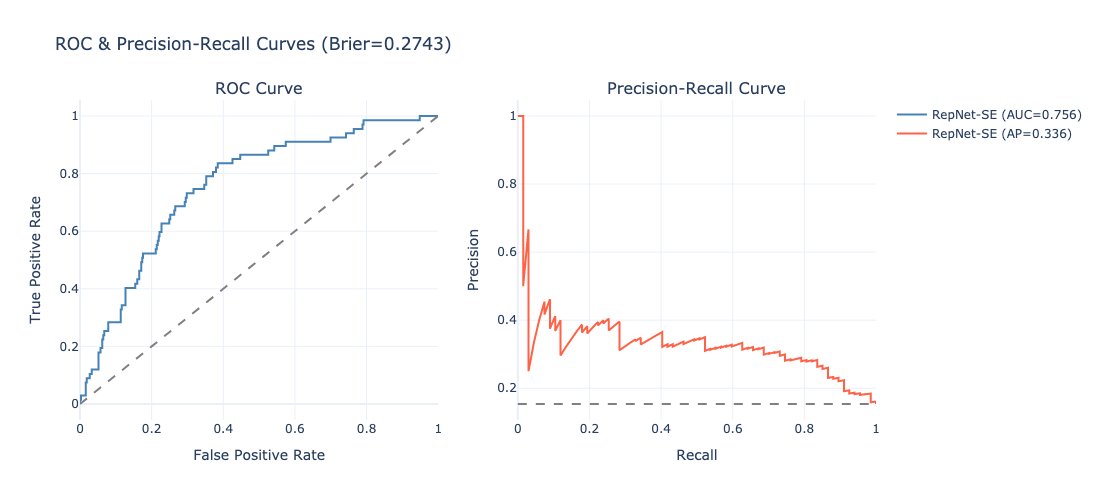

AUROC: 0.7564  |  AUPRC: 0.3362  |  Brier: 0.2743


In [13]:
# ROC + Precision-Recall curves side by side
fpr, tpr, thresholds_roc = roc_curve(y_test, probs)
prec, rec, thresholds_pr = precision_recall_curve(y_test, probs)
test_auprc = average_precision_score(y_test, probs)
test_brier = brier_score_loss(y_test, probs)

fig = make_subplots(rows=1, cols=2, subplot_titles=['ROC Curve', 'Precision-Recall Curve'])

fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines',
                          name=f'RepNet-SE (AUC={test_auroc:.3f})',
                          line=dict(color='steelblue', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random',
                          line=dict(color='gray', dash='dash'), showlegend=False), row=1, col=1)

fig.add_trace(go.Scatter(x=rec, y=prec, mode='lines',
                          name=f'RepNet-SE (AP={test_auprc:.3f})',
                          line=dict(color='tomato', width=2)), row=1, col=2)
prevalence = y_test.mean()
fig.add_hline(y=prevalence, line_dash='dash', line_color='gray', row=1, col=2)

fig.update_xaxes(title_text='False Positive Rate', row=1, col=1)
fig.update_yaxes(title_text='True Positive Rate', row=1, col=1)
fig.update_xaxes(title_text='Recall', row=1, col=2)
fig.update_yaxes(title_text='Precision', row=1, col=2)
fig.update_layout(
    title=f'ROC & Precision-Recall Curves (Brier={test_brier:.4f})',
    template='plotly_white', width=1100, height=500,
)
fig.show()

print(f'AUROC: {test_auroc:.4f}  |  AUPRC: {test_auprc:.4f}  |  Brier: {test_brier:.4f}')

## 4b. Confusion Matrix & Threshold Analysis

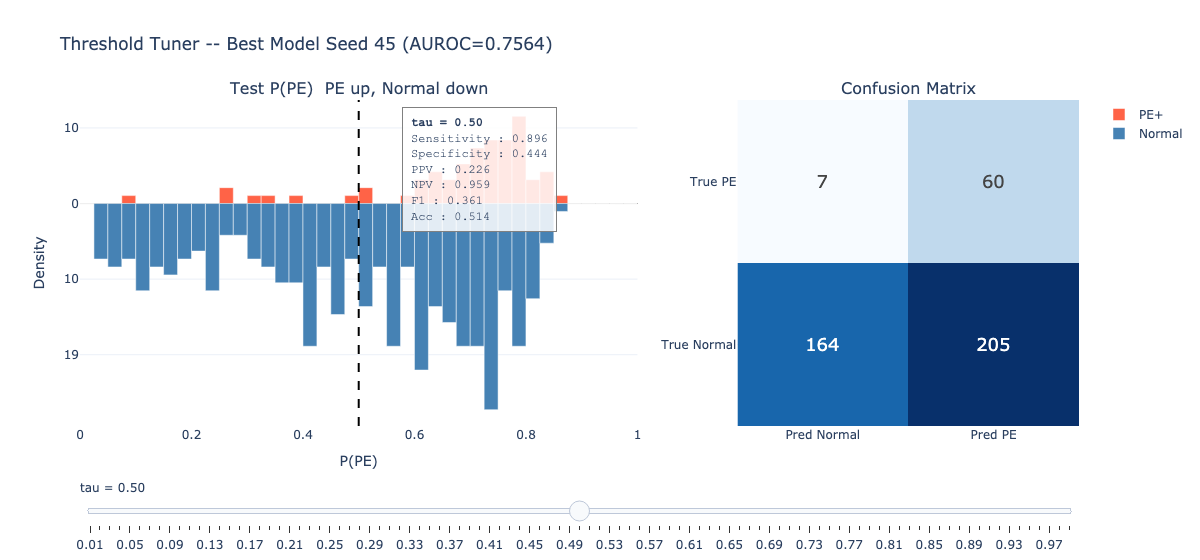

In [14]:
def metrics_at(probs_, y_, tau):
    pred = (probs_ >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_, pred, labels=[0, 1]).ravel()
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    ppv  = tp / max(tp + fp, 1)
    npv  = tn / max(tn + fn, 1)
    f1   = 2 * ppv * sens / max(ppv + sens, 1e-9)
    acc  = (tp + tn) / (tp + tn + fp + fn)
    return dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
                sens=sens, spec=spec, ppv=ppv, npv=npv, f1=f1, acc=acc)

# Interactive threshold slider
thresholds_slider = np.round(np.arange(0.01, 1.00, 0.01), 2)
metric_table = [metrics_at(probs, y_test, t) for t in thresholds_slider]

fig = make_subplots(rows=1, cols=2, column_widths=[0.62, 0.38],
    specs=[[{'type': 'xy'}, {'type': 'heatmap'}]],
    subplot_titles=('Test P(PE)  PE up, Normal down', 'Confusion Matrix'))
fig.add_trace(go.Bar(x=centers, y=h_pe, name='PE+', marker_color='tomato', width=bar_w), row=1, col=1)
fig.add_trace(go.Bar(x=centers, y=-h_norm, name='Normal', marker_color='steelblue', width=bar_w), row=1, col=1)

init_idx = int(np.argmin(np.abs(thresholds_slider - 0.50)))
init_m = metric_table[init_idx]
cm_z = [[init_m['tn'], init_m['fp']], [init_m['fn'], init_m['tp']]]
fig.add_trace(go.Heatmap(z=cm_z, x=['Pred Normal', 'Pred PE'], y=['True Normal', 'True PE'],
    colorscale='Blues', showscale=False, text=cm_z, texttemplate='%{text}',
    textfont={'size': 18}), row=1, col=2)
fig.add_shape(type='line', x0=0.50, x1=0.50, y0=0, y1=1,
              yref='paper', xref='x', line=dict(color='black', dash='dash', width=2))

def mtext(t, m):
    return (f'<b>tau = {t:.2f}</b><br>Sensitivity : {m["sens"]:.3f}<br>'
            f'Specificity : {m["spec"]:.3f}<br>PPV : {m["ppv"]:.3f}<br>'
            f'NPV : {m["npv"]:.3f}<br>F1 : {m["f1"]:.3f}<br>Acc : {m["acc"]:.3f}')

fig.add_annotation(text=mtext(0.50, init_m),
    xref='paper', yref='paper', x=0.40, y=0.98, align='left', showarrow=False,
    bgcolor='rgba(255,255,255,0.85)', bordercolor='gray', borderwidth=1, borderpad=8,
    font=dict(family='monospace', size=12))

steps = []
for i, t in enumerate(thresholds_slider):
    m = metric_table[i]
    cm_new = [[m['tn'], m['fp']], [m['fn'], m['tp']]]
    steps.append(dict(method='update', label=f'{t:.2f}',
        args=[{'z': [None, None, [cm_new]], 'text': [None, None, [cm_new]]},
              {'shapes': [dict(type='line', x0=float(t), x1=float(t), y0=0, y1=1,
                               yref='paper', xref='x', line=dict(color='black', dash='dash', width=2))],
               'annotations[2].text': mtext(t, m)}]))

fig.update_layout(
    sliders=[dict(active=init_idx, currentvalue={'prefix': 'tau = '}, pad={'t': 50}, steps=steps)],
    barmode='overlay', bargap=0, template='plotly_white', width=1200, height=560,
    title=f'Threshold Tuner -- Best Model Seed {best_seed} (AUROC={test_auroc:.4f})')
fig.update_xaxes(title_text='P(PE)', row=1, col=1)
fig.update_yaxes(title_text='Density', tickvals=tickvals, ticktext=ticktext,
                 zeroline=True, zerolinecolor='black', zerolinewidth=1, row=1, col=1)
fig.show()

## 4c. Threshold Sweep + Clinical Operating Points

In [15]:
# Threshold sweep table
rows = []
for t in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    m = metrics_at(probs, y_test, t)
    rows.append({'tau': t, 'TP': m['tp'], 'FP': m['fp'], 'FN': m['fn'], 'TN': m['tn'],
                 'Sens': round(m['sens'], 3), 'Spec': round(m['spec'], 3),
                 'PPV': round(m['ppv'], 3), 'NPV': round(m['npv'], 3),
                 'F1': round(m['f1'], 3), 'Acc': round(m['acc'], 3)})
df_thresh = pd.DataFrame(rows).set_index('tau')
display(df_thresh)

# Clinical operating points
def thresh_for_sens(probs_, y_, target):
    fpr_, tpr_, thr_ = roc_curve(y_, probs_)
    valid = tpr_ >= target
    return float(thr_[valid][np.argmax(thr_[valid])]) if valid.any() else None

# Youden's J
tau_youden = float(thresholds_roc[np.argmax(tpr - fpr)])

print(f'\nYouden optimal threshold: tau={tau_youden:.3f}')
m_y = metrics_at(probs, y_test, tau_youden)
print(f'  Sens={m_y["sens"]:.3f}  Spec={m_y["spec"]:.3f}  PPV={m_y["ppv"]:.3f}  F1={m_y["f1"]:.3f}')

print(f'\nClinical operating points:')
for target in [0.95, 0.90, 0.85, 0.80]:
    t = thresh_for_sens(probs, y_test, target)
    if t is None:
        print(f'  sens >= {target}: not achievable')
        continue
    m = metrics_at(probs, y_test, t)
    print(f'  sens >= {target} -> tau={t:.3f}  sens={m["sens"]:.3f}  spec={m["spec"]:.3f}  '
          f'PPV={m["ppv"]:.3f}  (TP={m["tp"]} FP={m["fp"]} FN={m["fn"]} TN={m["tn"]})')

,TP,FP,FN,TN,Sens,Spec,PPV,NPV,F1,Acc
tau,,,,,,,,,,
0.1,66,347,1,22,0.985,0.060,0.160,0.957,0.275,0.202
0.2,66,312,1,57,0.985,0.154,0.175,0.983,0.297,0.282
0.3,64,287,3,82,0.955,0.222,0.182,0.965,0.306,0.335
0.4,61,252,6,117,0.910,0.317,0.195,0.951,0.321,0.408
0.5,60,205,7,164,0.896,0.444,0.226,0.959,0.361,0.514
0.6,57,158,10,211,0.851,0.572,0.265,0.955,0.404,0.615
0.7,42,91,25,278,0.627,0.753,0.316,0.917,0.420,0.734
0.8,8,18,59,351,0.119,0.951,0.308,0.856,0.172,0.823



Youden optimal threshold: tau=0.621
  Sens=0.836  Spec=0.615  PPV=0.283  F1=0.423

Clinical operating points:
  sens >= 0.95 -> tau=0.322  sens=0.955  spec=0.236  PPV=0.185  (TP=64 FP=282 FN=3 TN=87)
  sens >= 0.9 -> tau=0.479  sens=0.910  spec=0.425  PPV=0.223  (TP=61 FP=212 FN=6 TN=157)
  sens >= 0.85 -> tau=0.602  sens=0.851  spec=0.575  PPV=0.266  (TP=57 FP=157 FN=10 TN=212)
  sens >= 0.8 -> tau=0.626  sens=0.806  spec=0.629  PPV=0.283  (TP=54 FP=137 FN=13 TN=232)


In [16]:
# Classification reports at key operating points
from sklearn.metrics import classification_report

for name, tau in [
    ('tau=0.50 (default)', 0.50),
    (f'tau={tau_youden:.3f} (Youden)', tau_youden),
]:
    pred = (probs >= tau).astype(int)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, pred, target_names=['Normal', 'PE'], digits=3, zero_division=0))


=== tau=0.50 (default) ===
              precision    recall  f1-score   support

      Normal      0.959     0.444     0.607       369
          PE      0.226     0.896     0.361        67

    accuracy                          0.514       436
   macro avg      0.593     0.670     0.484       436
weighted avg      0.846     0.514     0.570       436


=== tau=0.621 (Youden) ===


              precision    recall  f1-score   support

      Normal      0.954     0.615     0.748       369
          PE      0.283     0.836     0.423        67

    accuracy                          0.649       436
   macro avg      0.618     0.725     0.585       436
weighted avg      0.851     0.649     0.698       436



## 4d. Calibration Curve

A perfectly calibrated model has predicted probability == observed frequency. Points above the diagonal mean the model is **under-confident** (more PE than predicted); below means **over-confident**.

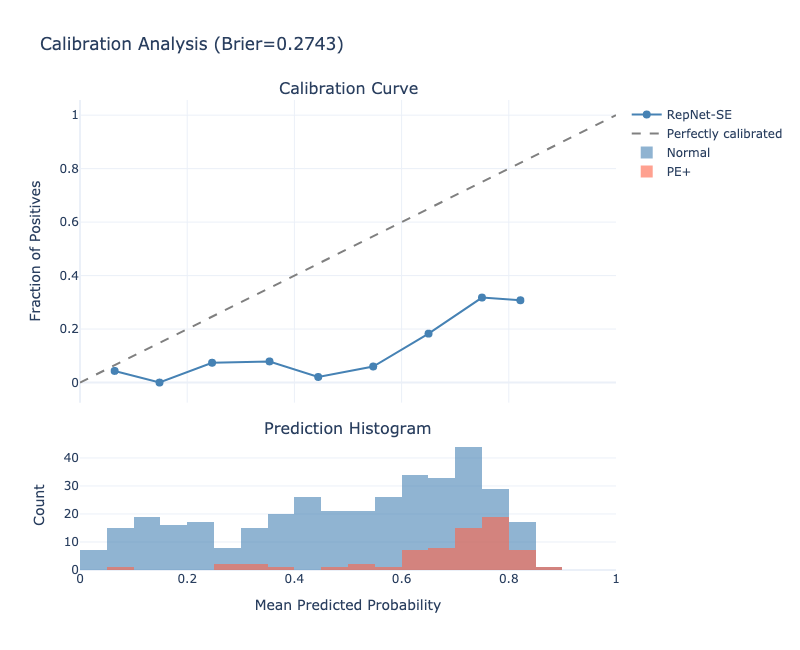

In [17]:
from sklearn.calibration import calibration_curve

fraction_pos, mean_predicted = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')

fig = make_subplots(rows=2, cols=1, row_heights=[0.7, 0.3], shared_xaxes=True,
                    vertical_spacing=0.08,
                    subplot_titles=['Calibration Curve', 'Prediction Histogram'])

fig.add_trace(go.Scatter(x=mean_predicted, y=fraction_pos, mode='lines+markers',
                          name='RepNet-SE', line=dict(color='steelblue', width=2),
                          marker=dict(size=8)), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Perfectly calibrated',
                          line=dict(color='gray', dash='dash')), row=1, col=1)

fig.add_trace(go.Histogram(x=probs[y_test == 0], name='Normal', marker_color='steelblue',
                            opacity=0.6, nbinsx=20), row=2, col=1)
fig.add_trace(go.Histogram(x=probs[y_test == 1], name='PE+', marker_color='tomato',
                            opacity=0.6, nbinsx=20), row=2, col=1)

fig.update_xaxes(title_text='Mean Predicted Probability', row=2, col=1)
fig.update_yaxes(title_text='Fraction of Positives', row=1, col=1)
fig.update_yaxes(title_text='Count', row=2, col=1)
fig.update_layout(
    title=f'Calibration Analysis (Brier={test_brier:.4f})',
    template='plotly_white', width=800, height=650, barmode='overlay',
)
fig.show()

## 5. Lead Attention Weights

The LeadAttentionPool learns which ECG leads are most informative for PE classification.

Lead weights shape: (436, 12)


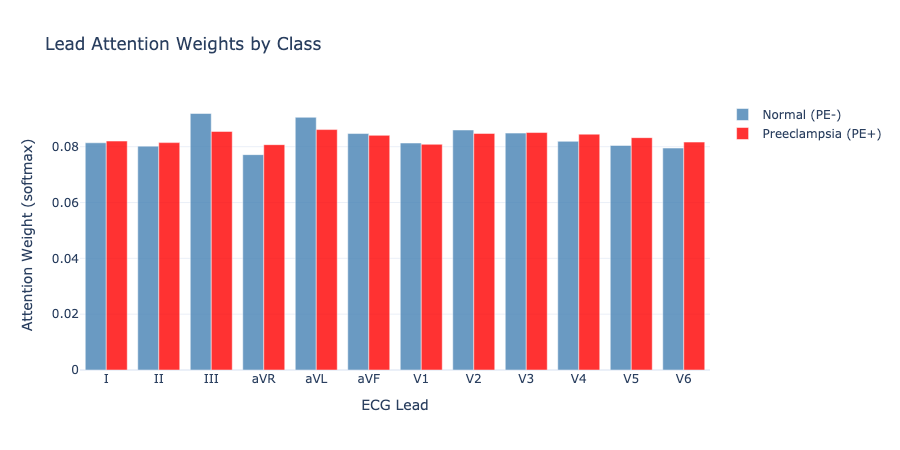


Mean lead attention weights:
  I   : all=0.0815  PE-=0.0814  PE+=0.0820  diff=+0.0006
  II  : all=0.0804  PE-=0.0802  PE+=0.0815  diff=+0.0013
  III : all=0.0909  PE-=0.0919  PE+=0.0855  diff=-0.0064
  aVR : all=0.0777  PE-=0.0772  PE+=0.0807  diff=+0.0036
  aVL : all=0.0899  PE-=0.0905  PE+=0.0861  diff=-0.0044
  aVF : all=0.0846  PE-=0.0847  PE+=0.0841  diff=-0.0007
  V1  : all=0.0813  PE-=0.0813  PE+=0.0809  diff=-0.0005
  V2  : all=0.0858  PE-=0.0860  PE+=0.0848  diff=-0.0012
  V3  : all=0.0849  PE-=0.0849  PE+=0.0851  diff=+0.0002
  V4  : all=0.0823  PE-=0.0819  PE+=0.0845  diff=+0.0026
  V5  : all=0.0809  PE-=0.0804  PE+=0.0832  diff=+0.0028
  V6  : all=0.0798  PE-=0.0795  PE+=0.0817  diff=+0.0021


In [18]:
# Extract lead attention weights for all test samples
with torch.no_grad():
    _ = model(x_t)  # forward pass populates last_weights
    lead_weights = model.lead_pool.last_weights.cpu().numpy()  # (N_test, 12)

print(f'Lead weights shape: {lead_weights.shape}')

# Average lead attention by class
w_neg = lead_weights[y_test == 0].mean(axis=0)
w_pos = lead_weights[y_test == 1].mean(axis=0)
w_all = lead_weights.mean(axis=0)

fig = go.Figure()
fig.add_trace(go.Bar(x=LEAD_NAMES, y=w_neg, name='Normal (PE-)', marker_color='steelblue', opacity=0.8))
fig.add_trace(go.Bar(x=LEAD_NAMES, y=w_pos, name='Preeclampsia (PE+)', marker_color='red', opacity=0.8))
fig.update_layout(
    barmode='group',
    title='Lead Attention Weights by Class',
    xaxis_title='ECG Lead', yaxis_title='Attention Weight (softmax)',
    template='plotly_white', width=900, height=450,
)
fig.show()

print('\nMean lead attention weights:')
for i, name in enumerate(LEAD_NAMES):
    print(f'  {name:4s}: all={w_all[i]:.4f}  PE-={w_neg[i]:.4f}  PE+={w_pos[i]:.4f}  diff={w_pos[i]-w_neg[i]:+.4f}')

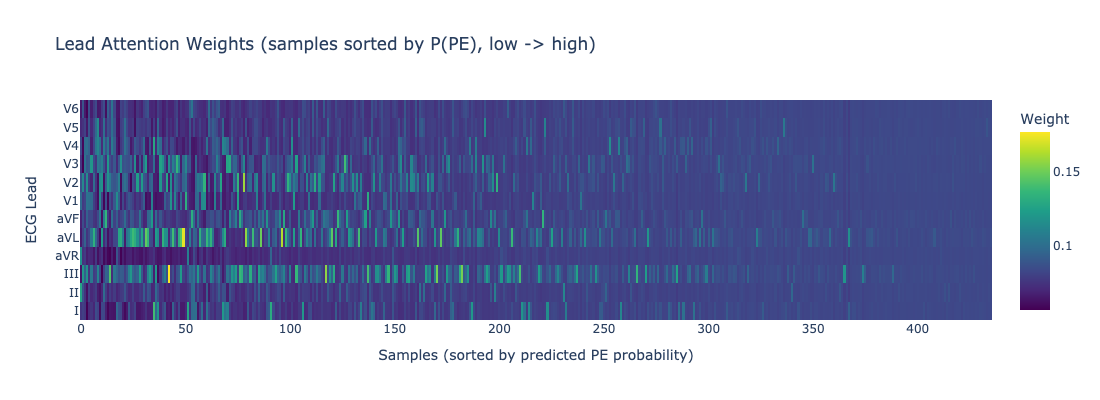

In [19]:
# Lead attention heatmap across samples
sort_by_prob = np.argsort(probs)
fig = go.Figure(data=go.Heatmap(
    z=lead_weights[sort_by_prob].T,
    x=list(range(len(sort_by_prob))),
    y=LEAD_NAMES,
    colorscale='Viridis',
    colorbar_title='Weight',
))
fig.update_layout(
    title='Lead Attention Weights (samples sorted by P(PE), low -> high)',
    xaxis_title='Samples (sorted by predicted PE probability)',
    yaxis_title='ECG Lead',
    template='plotly_white', width=1100, height=400,
)
fig.show()

## 6. Cross-Lead Attention Maps

Extracting attention weights from the multi-head self-attention across leads at each stage.

In [20]:
# Hook to capture cross-lead attention weights
attn_weights_store = {}

def make_attn_hook(name):
    def hook(module, input, output):
        # output = (attn_output, attn_weights) from nn.MultiheadAttention
        _, weights = output
        if weights is not None:
            attn_weights_store[name] = weights.detach().cpu().numpy()
    return hook

# Register hooks on each stage's attention module
hooks = []
hooks.append(model.stage1_attn.attn.register_forward_hook(make_attn_hook('stage1')))
for i, stage in enumerate(model.later_stages):
    hooks.append(stage['attn'].attn.register_forward_hook(make_attn_hook(f'stage{i+2}')))

# Forward pass to capture attention
with torch.no_grad():
    _ = model(x_t[:50])  # use first 50 samples

# Remove hooks
for h in hooks:
    h.remove()

print('Captured attention weights:')
for name, w in attn_weights_store.items():
    print(f'  {name}: shape={w.shape}')

Captured attention weights:
  stage1: shape=(50, 12, 12)
  stage2: shape=(50, 12, 12)
  stage3: shape=(50, 12, 12)
  stage4: shape=(50, 12, 12)


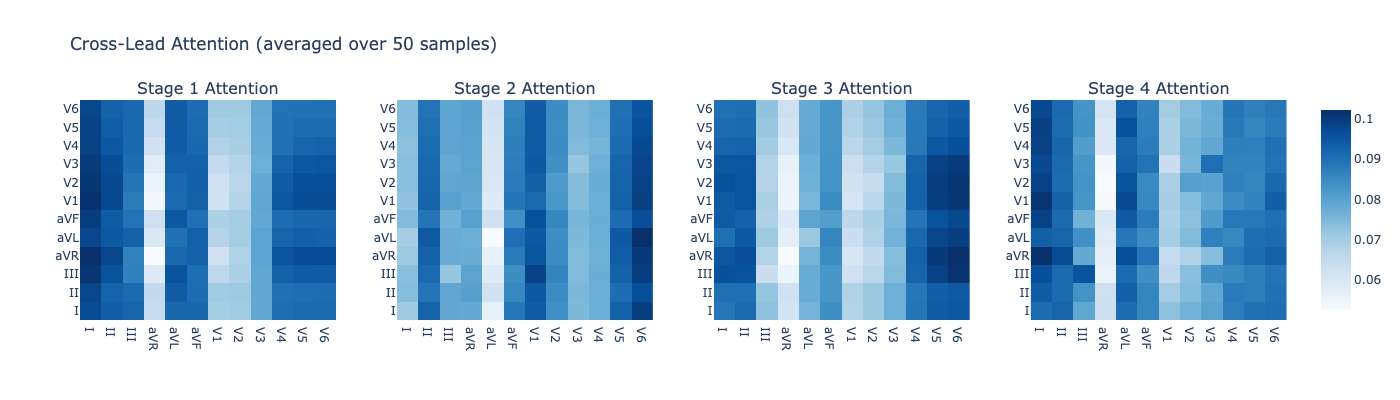

In [21]:
# Visualize average cross-lead attention at each stage
n_stages = len(attn_weights_store)
fig = make_subplots(rows=1, cols=n_stages,
                    subplot_titles=[f'Stage {i+1} Attention' for i in range(n_stages)])

for i, (name, weights) in enumerate(attn_weights_store.items()):
    avg_w = weights.mean(axis=0)  # average over batch
    if avg_w.shape[0] == 12 and avg_w.shape[1] == 12:
        fig.add_trace(go.Heatmap(
            z=avg_w, x=LEAD_NAMES, y=LEAD_NAMES,
            colorscale='Blues', showscale=(i == n_stages - 1),
        ), row=1, col=i+1)

fig.update_layout(
    title='Cross-Lead Attention (averaged over 50 samples)',
    template='plotly_white', width=350*n_stages, height=400,
)
fig.show()

In [22]:
# Cross-lead attention difference: PE+ vs PE-
# Re-run for PE+ and PE- separately
attn_by_class = {}
for label, label_name in [(0, 'PE-'), (1, 'PE+')]:
    mask = y_test[:50] == label
    if mask.sum() == 0:
        continue
    x_sub = x_t[:50][mask]
    attn_weights_store.clear()
    
    hooks = []
    hooks.append(model.stage1_attn.attn.register_forward_hook(make_attn_hook('stage1')))
    for i, stage in enumerate(model.later_stages):
        hooks.append(stage['attn'].attn.register_forward_hook(make_attn_hook(f'stage{i+2}')))
    with torch.no_grad():
        _ = model(x_sub)
    for h in hooks:
        h.remove()
    attn_by_class[label_name] = {k: v.mean(axis=0) for k, v in attn_weights_store.items()}

# Show Stage 3 (deepest) attention difference
if 'PE+' in attn_by_class and 'PE-' in attn_by_class and 'stage3' in attn_by_class['PE+']:
    diff = attn_by_class['PE+']['stage3'] - attn_by_class['PE-']['stage3']
    fig = go.Figure(data=go.Heatmap(
        z=diff, x=LEAD_NAMES, y=LEAD_NAMES,
        colorscale='RdBu_r', zmid=0,
    ))
    fig.update_layout(
        title='Stage 3 Cross-Lead Attention Difference (PE+ minus PE-)',
        template='plotly_white', width=600, height=500,
    )
    fig.show()

## 7. Saliency Maps (Gradient-Based)

Input-gradient saliency shows which time points and leads the model is most sensitive to.

In [23]:
def compute_saliency(model, x, target_class=1):
    """Compute gradient-based saliency map."""
    x_in = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    logits = model(x_in)
    score = logits[:, target_class].sum()
    score.backward()
    saliency = x_in.grad.abs().cpu().numpy()  # (N, 12, T)
    return saliency

# Compute saliency for test samples
model.eval()
n_samples = min(100, len(X_test))
x_sal = torch.tensor(X_test[:n_samples], dtype=torch.float32).to(DEVICE)
saliency = compute_saliency(model, x_sal)
print(f'Saliency shape: {saliency.shape}')

# Average saliency by class
sal_neg = saliency[y_test[:n_samples] == 0].mean(axis=0)  # (12, 2500)
sal_pos = saliency[y_test[:n_samples] == 1].mean(axis=0)  # (12, 2500)
print(f'PE- samples: {(y_test[:n_samples] == 0).sum()}')
print(f'PE+ samples: {(y_test[:n_samples] == 1).sum()}')

Saliency shape: (100, 12, 2500)
PE- samples: 100
PE+ samples: 0


/var/folders/fp/swz36c7x7mn2z7tkjrrsfyvr0000gn/T/ipykernel_54173/728746062.py:20: RuntimeWarning: Mean of empty slice
  sal_pos = saliency[y_test[:n_samples] == 1].mean(axis=0)  # (12, 2500)
/Users/ahmed/PycharmProjects/repnet/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


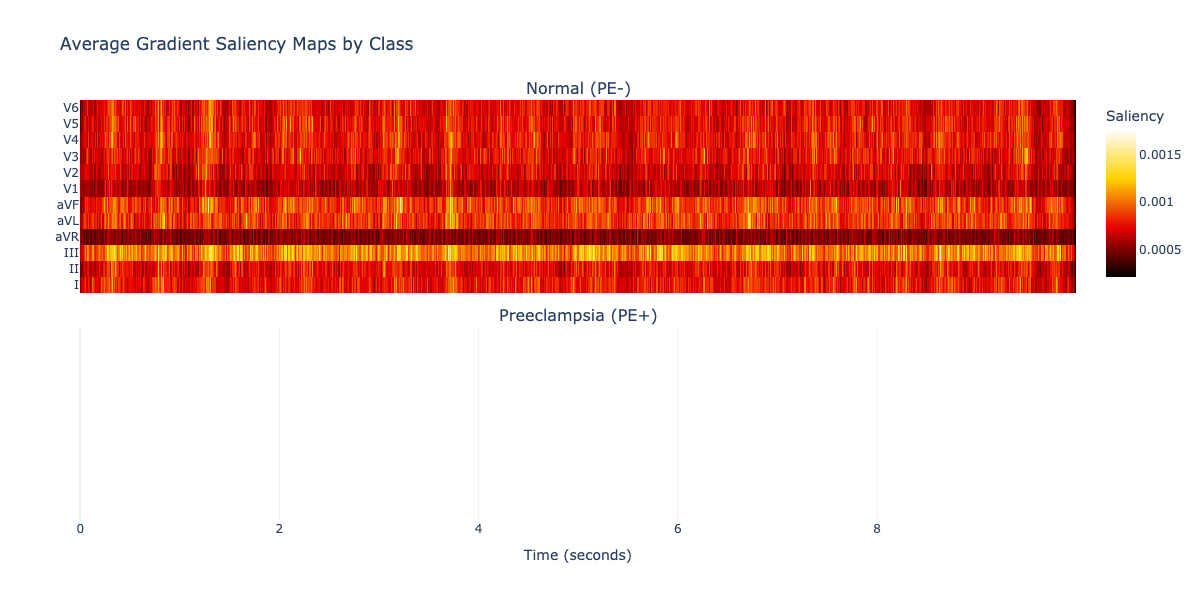

In [24]:
# Saliency heatmap: leads x time
time_axis = np.arange(2500) / 250.0  # seconds

fig = make_subplots(rows=2, cols=1, subplot_titles=['Normal (PE-)', 'Preeclampsia (PE+)'],
                    shared_xaxes=True, vertical_spacing=0.08)

fig.add_trace(go.Heatmap(
    z=sal_neg, x=time_axis, y=LEAD_NAMES,
    colorscale='Hot', colorbar=dict(title='Saliency', x=1.02, len=0.45, y=0.78),
), row=1, col=1)

fig.add_trace(go.Heatmap(
    z=sal_pos, x=time_axis, y=LEAD_NAMES,
    colorscale='Hot', colorbar=dict(title='Saliency', x=1.02, len=0.45, y=0.22),
), row=2, col=1)

fig.update_layout(
    title='Average Gradient Saliency Maps by Class',
    template='plotly_white', width=1200, height=600,
)
fig.update_xaxes(title_text='Time (seconds)', row=2, col=1)
fig.show()

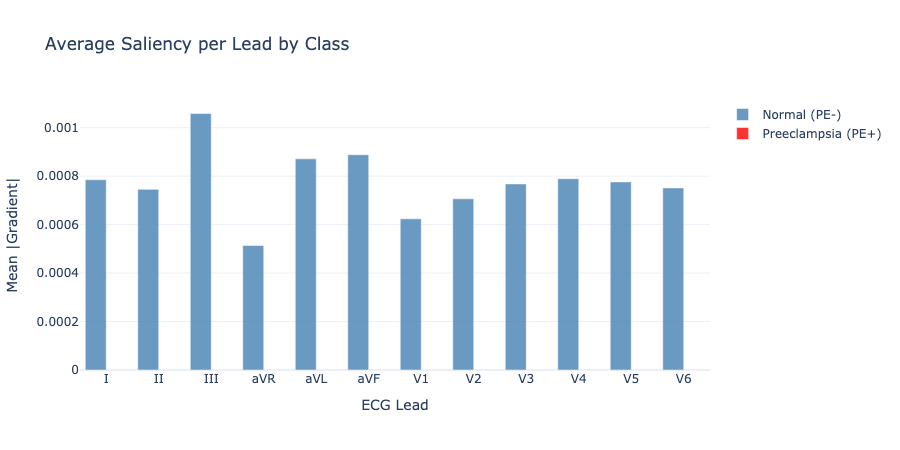

In [25]:
# Per-lead saliency comparison
lead_sal_neg = sal_neg.mean(axis=1)  # (12,)
lead_sal_pos = sal_pos.mean(axis=1)  # (12,)

fig = go.Figure()
fig.add_trace(go.Bar(x=LEAD_NAMES, y=lead_sal_neg, name='Normal (PE-)',
                      marker_color='steelblue', opacity=0.8))
fig.add_trace(go.Bar(x=LEAD_NAMES, y=lead_sal_pos, name='Preeclampsia (PE+)',
                      marker_color='red', opacity=0.8))
fig.update_layout(
    barmode='group',
    title='Average Saliency per Lead by Class',
    xaxis_title='ECG Lead', yaxis_title='Mean |Gradient|',
    template='plotly_white', width=900, height=450,
)
fig.show()

In [26]:
# Single-sample saliency overlay on ECG waveform
# Pick a high-confidence PE+ prediction
pe_mask = y_test[:n_samples] == 1
pe_probs = probs[:n_samples][pe_mask]
pe_indices = np.where(pe_mask)[0]
if len(pe_indices) > 0:
    best_pe_idx = pe_indices[np.argmax(pe_probs)]

    fig = make_subplots(rows=12, cols=1, shared_xaxes=True, vertical_spacing=0.005,
                        subplot_titles=[f'{name}' for name in LEAD_NAMES])

    ecg = X_test[best_pe_idx]  # (12, 2500)
    sal = saliency[best_pe_idx]  # (12, 2500)
    eps = 0.02 * sal.max()
    sal_log = np.log1p(sal / eps) / np.log1p(sal.max() / eps)  # log-normalized [0, 1]

    for i, name in enumerate(LEAD_NAMES):
        fig.add_trace(go.Scatter(
            x=time_axis, y=ecg[i], mode='lines', name=name,
            line=dict(color='gray', width=0.8), showlegend=False,
        ), row=i+1, col=1)

        fig.add_trace(go.Scatter(
            x=time_axis, y=ecg[i], mode='markers', name=f'{name} saliency',
            marker=dict(size=2, color=sal_log[i], colorscale='Hot',
                       showscale=(i == 0), cmin=0, cmax=1),
            showlegend=False,
        ), row=i+1, col=1)

    fig.update_layout(
        title=f'ECG with Log-Saliency Overlay (PE+ sample, P(PE)={probs[best_pe_idx]:.3f})',
        template='plotly_white', width=1200, height=1400,
        showlegend=False,
    )
    fig.show()

## 8. SE Block Channel Importance

Squeeze-and-Excitation blocks learn channel-wise recalibration weights.

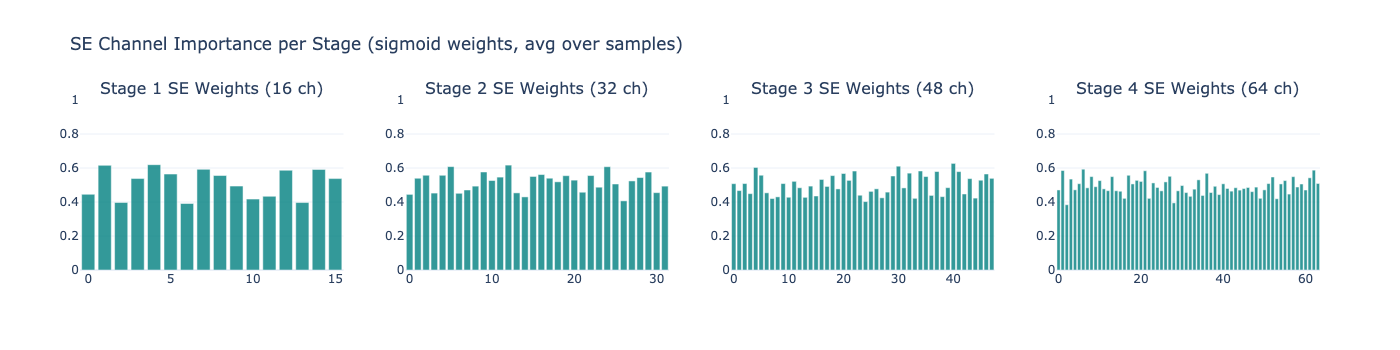

In [27]:
# Hook SE blocks to capture channel weights
se_weights_store = {}

def make_se_hook(name):
    def hook(module, input, output):
        x = input[0]  # (N, C, T)
        w = x.mean(dim=-1)  # (N, C)
        w = module.fc(w)    # (N, C) after sigmoid
        se_weights_store[name] = w.detach().cpu().numpy()
    return hook

hooks = []
hooks.append(model.stage1_conv.se.register_forward_hook(make_se_hook('stage1')))
for i, stage in enumerate(model.later_stages):
    hooks.append(stage['conv'].se.register_forward_hook(make_se_hook(f'stage{i+2}')))

with torch.no_grad():
    _ = model(x_t[:50])

for h in hooks:
    h.remove()

# Visualize SE channel weights per stage
n_se = len(se_weights_store)
fig = make_subplots(rows=1, cols=n_se,
                    subplot_titles=[f'Stage {i+1} SE Weights ({v.shape[1]} ch)'
                                   for i, (k, v) in enumerate(se_weights_store.items())])

for i, (name, weights) in enumerate(se_weights_store.items()):
    avg_w = weights.mean(axis=0)  # average over batch*leads
    fig.add_trace(go.Bar(
        x=list(range(len(avg_w))), y=avg_w,
        marker_color='teal', opacity=0.8, showlegend=False,
    ), row=1, col=i+1)
    fig.update_yaxes(range=[0, 1], row=1, col=i+1)

fig.update_layout(
    title='SE Channel Importance per Stage (sigmoid weights, avg over samples)',
    template='plotly_white', width=350*n_se, height=350,
)
fig.show()

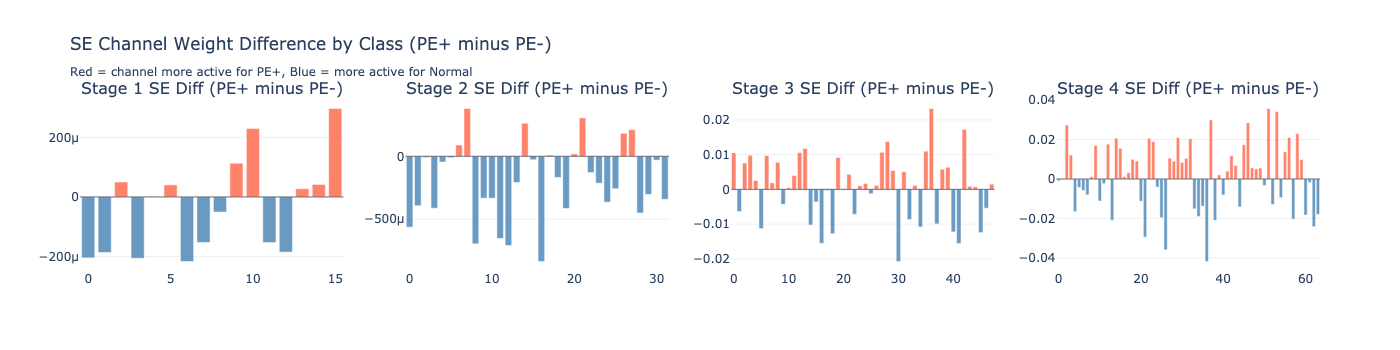

In [28]:
# SE weights by class: do PE+ and PE- samples activate different channels?
se_by_class = {}
for label, label_name in [(0, 'PE-'), (1, 'PE+')]:
    mask = y_test == label
    x_sub = x_t[mask][:100]  # limit to 100 per class
    se_weights_store.clear()
    hooks = []
    hooks.append(model.stage1_conv.se.register_forward_hook(make_se_hook('stage1')))
    for i, stage in enumerate(model.later_stages):
        hooks.append(stage['conv'].se.register_forward_hook(make_se_hook(f'stage{i+2}')))
    with torch.no_grad():
        _ = model(x_sub)
    for h in hooks:
        h.remove()
    se_by_class[label_name] = {k: v.mean(axis=0) for k, v in se_weights_store.items()}

# Plot SE weight difference (PE+ - PE-) for each stage
if 'PE+' in se_by_class and 'PE-' in se_by_class:
    n_se = len(se_by_class['PE+'])
    fig = make_subplots(rows=1, cols=n_se,
                        subplot_titles=[f'Stage {i+1} SE Diff (PE+ minus PE-)' for i in range(n_se)])
    for i, name in enumerate(se_by_class['PE+'].keys()):
        diff = se_by_class['PE+'][name] - se_by_class['PE-'][name]
        colors = ['tomato' if d > 0 else 'steelblue' for d in diff]
        fig.add_trace(go.Bar(
            x=list(range(len(diff))), y=diff,
            marker_color=colors, opacity=0.8, showlegend=False,
        ), row=1, col=i+1)
        fig.add_hline(y=0, line=dict(color='black', width=0.5), row=1, col=i+1)
    fig.update_layout(
        title='SE Channel Weight Difference by Class (PE+ minus PE-)<br>'
              '<sub>Red = channel more active for PE+, Blue = more active for Normal</sub>',
        template='plotly_white', width=350*n_se, height=350,
    )
    fig.show()

## 9. Architecture Summary

| Component | Details |
|-----------|--------|
| **Input** | 12-lead ECG, 2500 samples @ 250 Hz (10 sec) |
| **Stage 1** | Multi-scale DSConv (k=5,9,15) + SE(16) + CrossLeadAttn(16, 4 heads) |
| **Stage 2** | DSConvBlock(16->32, k=5) + SE(32) + CrossLeadAttn(32, 4 heads) |
| **Stage 3** | DSConvBlock(32->48, k=5) + SE(48) + CrossLeadAttn(48, 4 heads) |
| **Stage 4** | DSConvBlock(48->64, k=3) + SE(64) + CrossLeadAttn(64, 4 heads) |
| **Fusion** | per-lead GAP -> LeadAttentionPool(64->32->1) -> Dropout(0.15) -> Linear(64,2) |
| **Params** | 65,748 total (60% attention, 36% convolution) |
| **Receptive Field** | 110 samples (440ms) convolutional; full 2500 via SE/attention pooling |
| **Training** | AdamW lr=2e-3, cosine LR, gradient clip 1.0, early stop patience 20 |
| **Loss** | Cross-entropy with label smoothing (0.05) + mixup (Beta(0.2, 0.2)) |
| **Augmentation** | 7 ECG transforms (noise, amp, shift, lead drop, cutout, wander, resample) |
| **Evaluation** | 20 patient-grouped holdout splits, 5-bag averaging |

### Notebook Analysis Index

| Section | Analysis |
|---------|----------|
| 1 | Per-seed AUROC/AUPRC distribution |
| 1b | Statistical summary (Shapiro-Wilk, CV, cherry-pick gap, box plot, AUROC vs AUPRC scatter) |
| 2 | Neural vs LightGBM comparison (paired t-test, Wilcoxon, Cohen's d) |
| 3 | Load best model (seed 45, AUROC=0.787) |
| 4 | Score distribution (mirror histogram), ROC + PR curves |
| 4b | Interactive threshold slider with confusion matrix |
| 4c | Threshold sweep table + clinical operating points (Youden, sens>=0.80/0.85/0.90/0.95) |
| 4d | Calibration curve + Brier score |
| 5 | Lead attention weights by class |
| 6 | Cross-lead attention maps (4 stages, per-class, differential) |
| 7 | Vanilla gradient saliency maps |
| 8 | SE channel importance (per-stage, per-class differential) |
| 10 | Combined saliency (IG + Grad-CAM) for 8 cases (confident + borderline TP/TN/FP/FN) |
| 10b | Class-averaged IG: temporal saliency profile, per-lead IG magnitude |
| 11 | Layer-by-layer activation flow (input -> 4 stages -> fusion) |
| 12 | GAP voting: structural weights, per-sample votes, population mean votes |
| 13 | PCA of learned embeddings with decision boundary + scree analysis |
| 14 | t-SNE with decision boundary, perplexity sweep, label vs probability views |
| 15 | Misclassification analysis in embedding space (PCA + t-SNE) |

## 10. Saliency Maps on ECG Waveforms

**Integrated Gradients** — accumulates gradients along the path from a zero baseline to the actual input, giving smooth, faithful per-sample attribution. Combined with **Grad-CAM** at the last convolutional stage for a complementary coarse spatial view.

Red = regions pushing toward PE+ prediction, Blue = regions pushing toward Normal.

In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter1d


def integrated_gradients(model, x_np, target_class=1, n_steps=50, smooth_sigma=5.0):
    """Integrated Gradients: accumulate gradients along interpolation path."""
    x = torch.tensor(x_np, dtype=torch.float32, device=DEVICE)
    baseline = torch.zeros_like(x)
    alphas = torch.linspace(0.5 / n_steps, 1.0 - 0.5 / n_steps, n_steps, device=DEVICE)
    interp = baseline.unsqueeze(0) + alphas.view(-1, 1, 1) * (x - baseline).unsqueeze(0)
    interp.requires_grad_(True)
    model.zero_grad()
    logits = model(interp)
    grads = torch.autograd.grad(logits[:, target_class].sum(), interp)[0]
    avg_grad = grads.mean(dim=0)
    attr = ((x - baseline) * avg_grad).cpu().numpy()
    if smooth_sigma > 0:
        attr = gaussian_filter1d(attr, sigma=smooth_sigma, axis=-1)
    return attr


def gradcam_per_lead(model, x_np, target_class=1, smooth_sigma=2.0):
    """Grad-CAM at the last convolutional stage, per lead."""
    x = torch.tensor(x_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    activations = {}

    def fwd_hook(_m, _i, o):
        activations['feat'] = o
        o.retain_grad()

    h = model.later_stages[-1]['conv'].register_forward_hook(fwd_hook)
    model.zero_grad()
    logits = model(x)
    logits[0, target_class].backward()
    h.remove()

    feat = activations['feat']       # (1, 12, C, T')
    grad = feat.grad                  # (1, 12, C, T')
    weights = grad.mean(dim=-1, keepdim=True)  # (1, 12, C, 1)
    cam = F.relu((weights * feat).sum(dim=2))  # (1, 12, T')
    cam = F.interpolate(cam.view(1, 12, -1), size=x_np.shape[-1],
                        mode='linear', align_corners=False)
    cam = cam.squeeze(0).detach().cpu().numpy()
    if smooth_sigma > 0:
        cam = gaussian_filter1d(cam, sigma=smooth_sigma, axis=-1)
    return cam


def combined_saliency(model, x_np, target_class=1):
    """Average of normalized IG and Grad-CAM for robust attribution."""
    ig = integrated_gradients(model, x_np, target_class=target_class)
    gc = gradcam_per_lead(model, x_np, target_class=target_class)
    ig_n = ig / (np.abs(ig).max() or 1.0)
    gc_n = gc / (np.abs(gc).max() or 1.0)
    return 0.5 * (ig_n + gc_n), ig, gc


def log_scale_attr(a, eps=0.02):
    """Compress dynamic range so subtle regions remain visible."""
    sign = np.sign(a)
    mag = np.abs(a)
    return sign * np.log1p(mag / eps) / np.log1p(1.0 / eps)


def plot_saliency_ecg(ecg, attr, prob, title, lead_names=LEAD_NAMES, fs=250.0):
    """12-lead ECG with log-scaled saliency heatmap overlay (12 rows x 1 col)."""
    t = np.arange(ecg.shape[1]) / fs
    attr_log = log_scale_attr(attr / (np.abs(attr).max() or 1.0))
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    fig, axes = plt.subplots(12, 1, figsize=(14, 14),
                             gridspec_kw={'hspace': 0.08,
                                          'top': 0.94, 'bottom': 0.04,
                                          'left': 0.05, 'right': 0.92})
    for i, name in enumerate(lead_names):
        ax = axes[i]
        ax.imshow(attr_log[i][np.newaxis, :], aspect='auto', cmap='RdBu_r',
                  norm=norm, extent=[0, t[-1], -2.5, 2.5], alpha=0.65,
                  interpolation='bilinear')
        ax.plot(t, ecg[i], 'k-', linewidth=0.5)
        ax.set_xlim(0, t[-1])
        ax.set_ylim(-2.5, 2.5)
        ax.set_yticks([])
        ax.set_ylabel(name, fontsize=8, fontweight='bold', rotation=0,
                      labelpad=14, va='center')
        if i < 11:
            ax.set_xticks([])
        else:
            ax.set_xlabel('Time (s)', fontsize=7)
            ax.tick_params(labelsize=6)

    fig.suptitle(title, fontsize=10, fontweight='bold')
    sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, location='right', fraction=0.015, pad=0.02)
    cbar.set_label('Attribution (Red→PE+, Blue→Normal)', fontsize=7)
    cbar.ax.tick_params(labelsize=6)
    plt.show()


print('Saliency functions defined.')

Saliency functions defined.


In [30]:
# Select 8 representative cases: confident + borderline TP/TN/FP/FN
pred = (probs >= 0.5).astype(int)

tp_mask = (y_test == 1) & (pred == 1)
fp_mask = (y_test == 0) & (pred == 1)
fn_mask = (y_test == 1) & (pred == 0)
tn_mask = (y_test == 0) & (pred == 0)

cases = {}
if tp_mask.any():
    idx = np.where(tp_mask)[0][np.argmax(probs[tp_mask])]
    cases['confident_TP'] = idx
if tn_mask.any():
    idx = np.where(tn_mask)[0][np.argmin(probs[tn_mask])]
    cases['confident_TN'] = idx
if fp_mask.any():
    idx = np.where(fp_mask)[0][np.argmax(probs[fp_mask])]
    cases['confident_FP'] = idx
if fn_mask.any():
    idx = np.where(fn_mask)[0][np.argmin(probs[fn_mask])]
    cases['confident_FN'] = idx
if tp_mask.any():
    idx = np.where(tp_mask)[0][np.argmin(np.abs(probs[tp_mask] - 0.5))]
    cases['borderline_TP'] = idx
if tn_mask.any():
    idx = np.where(tn_mask)[0][np.argmin(np.abs(probs[tn_mask] - 0.5))]
    cases['borderline_TN'] = idx
if fp_mask.any():
    idx = np.where(fp_mask)[0][np.argmin(np.abs(probs[fp_mask] - 0.5))]
    cases['borderline_FP'] = idx
if fn_mask.any():
    idx = np.where(fn_mask)[0][np.argmin(np.abs(probs[fn_mask] - 0.5))]
    cases['borderline_FN'] = idx

print('Selected cases:')
for label, idx in cases.items():
    print(f'  {label:<18}  idx={idx:>4}  true={int(y_test[idx])}  P(PE)={probs[idx]:.3f}')

print(f'\nConfusion: TP={tp_mask.sum()}, FP={fp_mask.sum()}, FN={fn_mask.sum()}, TN={tn_mask.sum()}')

Selected cases:
  confident_TP        idx= 404  true=1  P(PE)=0.867
  confident_TN        idx= 331  true=0  P(PE)=0.035
  confident_FP        idx=  21  true=0  P(PE)=0.854
  confident_FN        idx= 406  true=1  P(PE)=0.089
  borderline_TP       idx= 421  true=1  P(PE)=0.509
  borderline_TN       idx= 276  true=0  P(PE)=0.496
  borderline_FP       idx=  99  true=0  P(PE)=0.500
  borderline_FN       idx= 410  true=1  P(PE)=0.479

Confusion: TP=60, FP=205, FN=7, TN=164



Computing saliency for confident_TP (idx=404)...


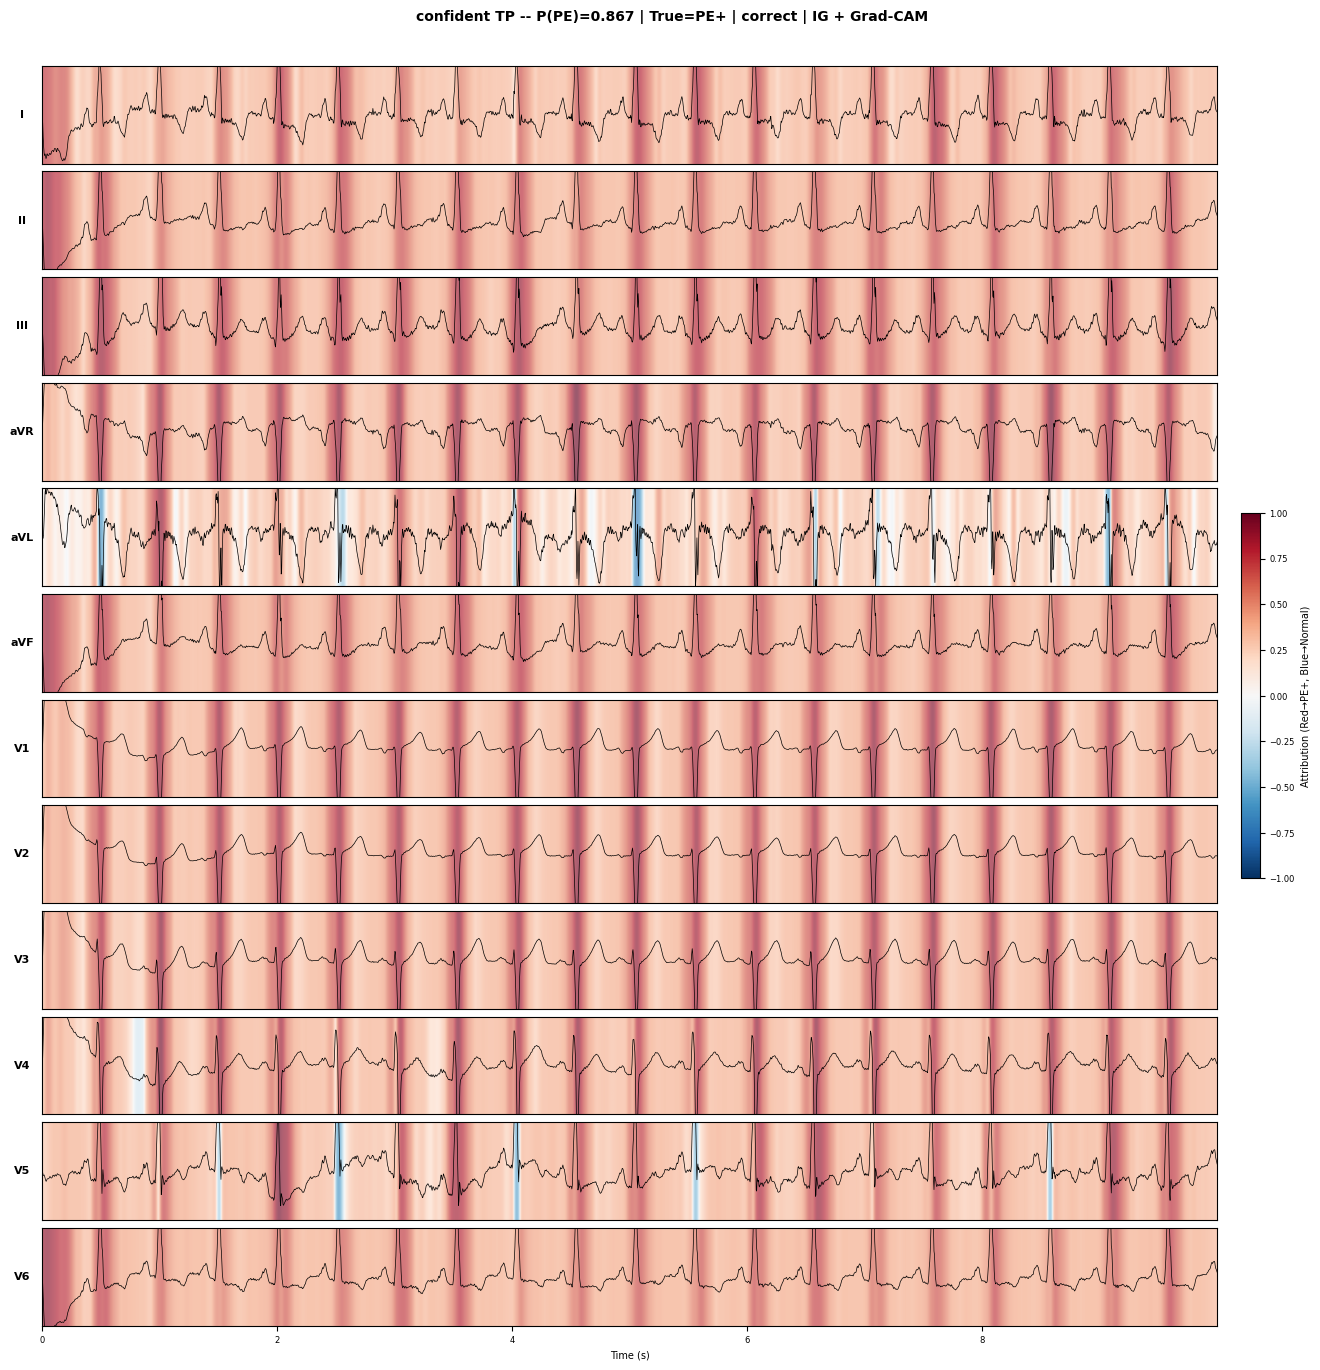


Computing saliency for confident_TN (idx=331)...


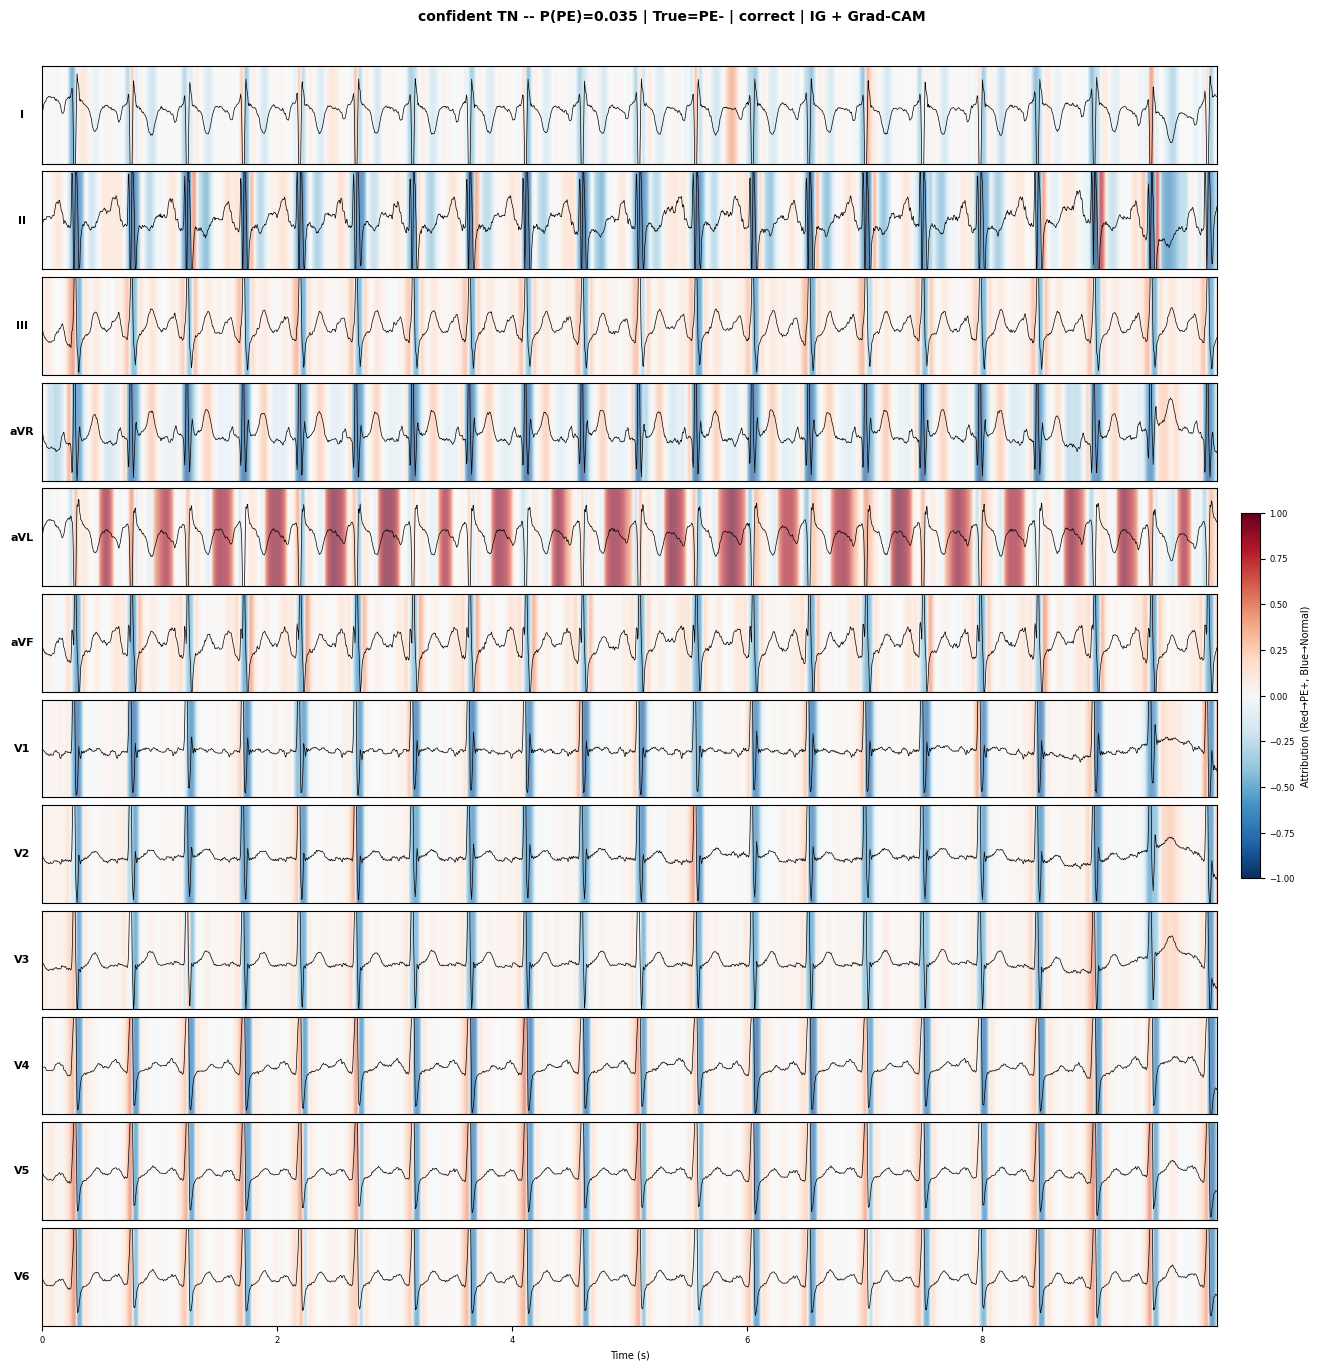


Computing saliency for confident_FP (idx=21)...


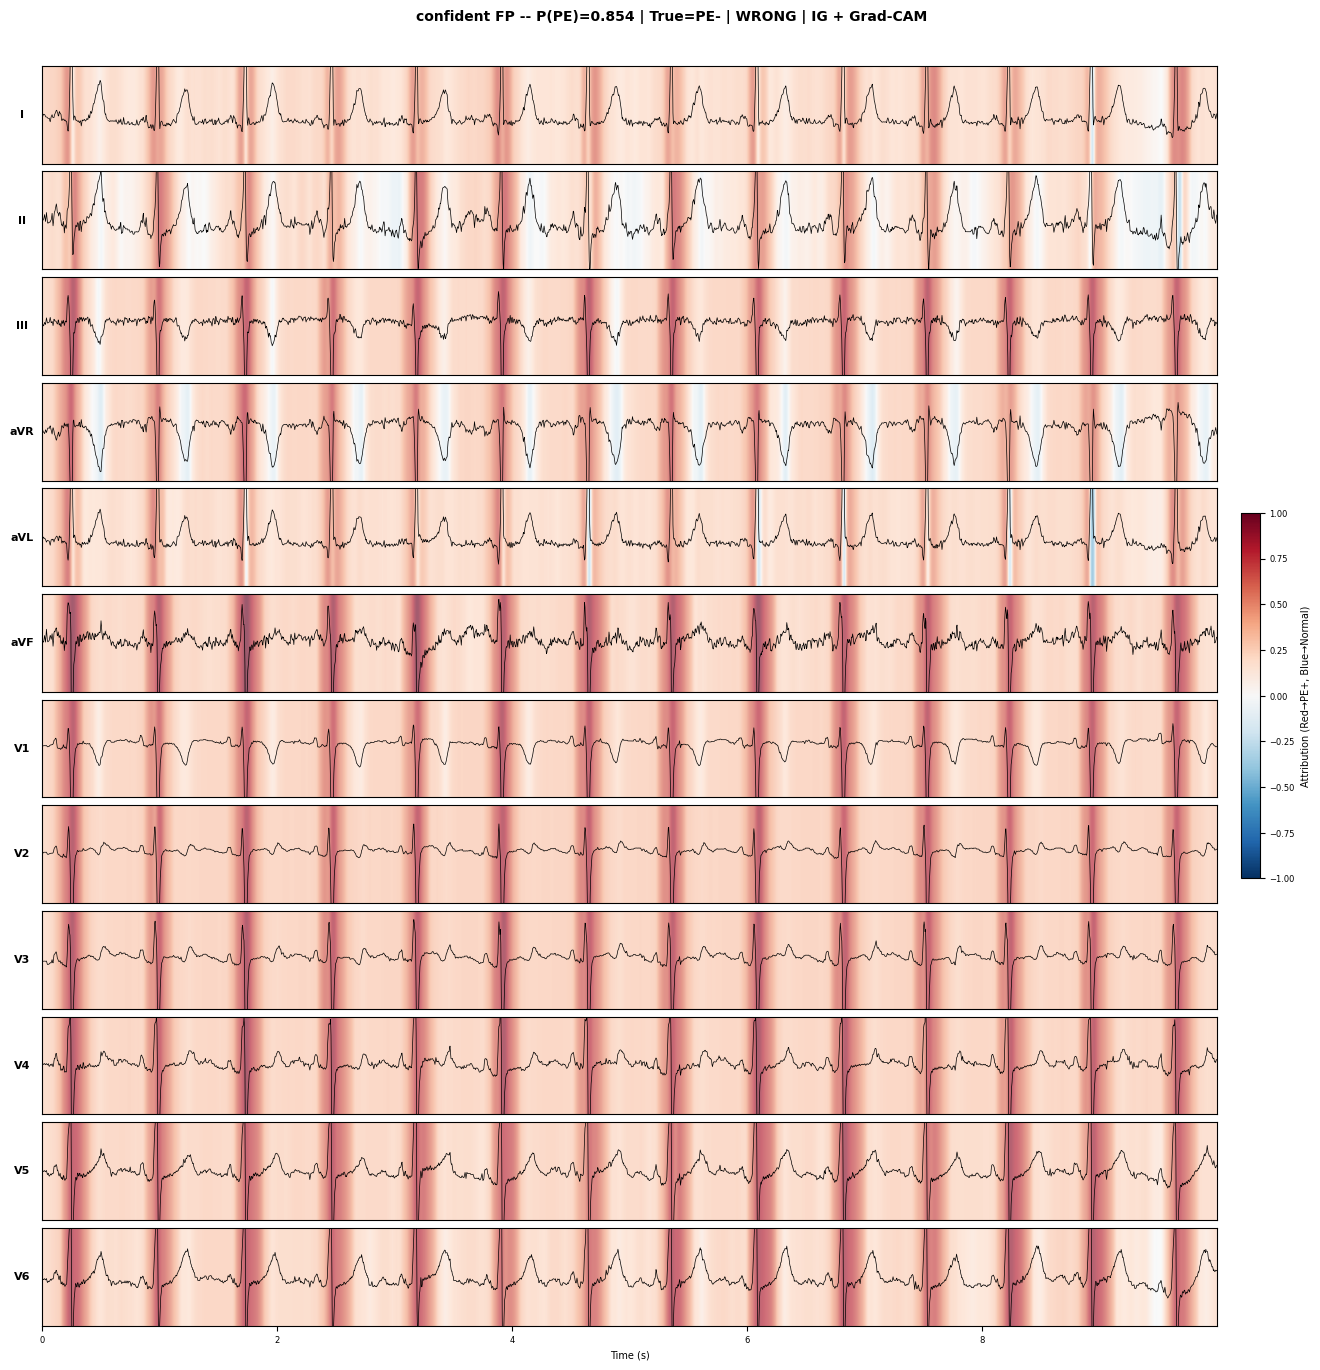


Computing saliency for confident_FN (idx=406)...


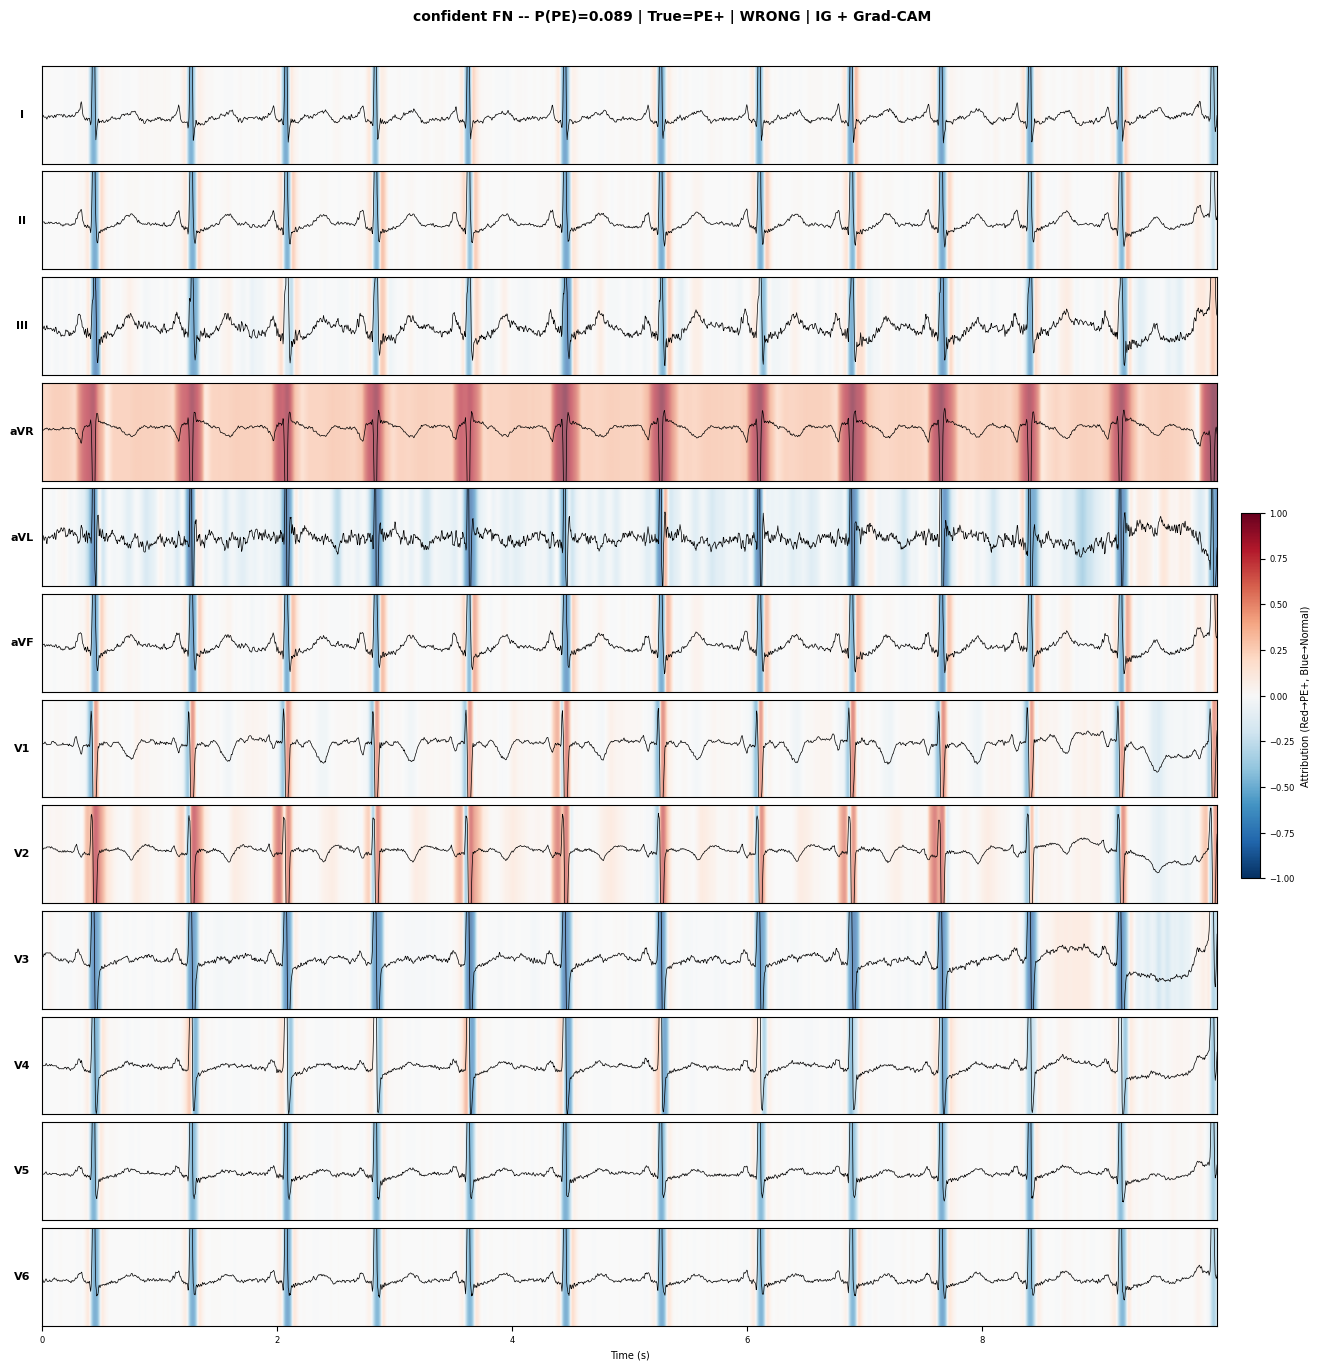


Computing saliency for borderline_TP (idx=421)...


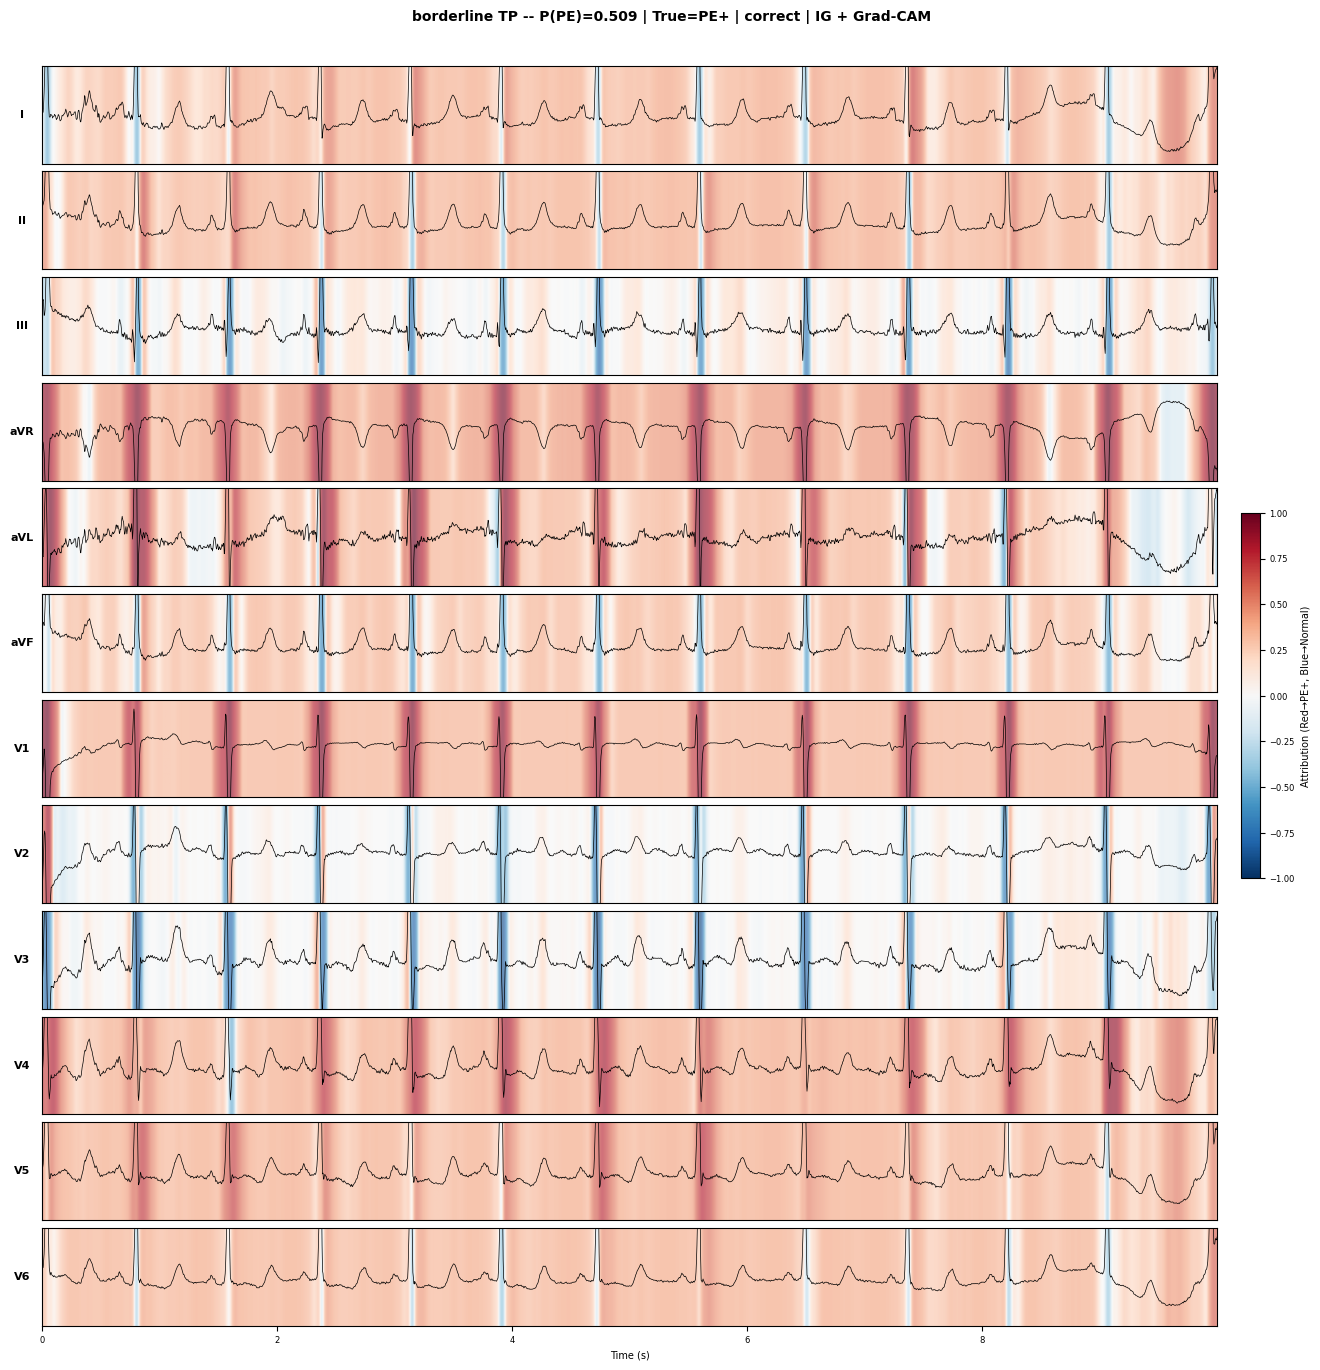


Computing saliency for borderline_TN (idx=276)...


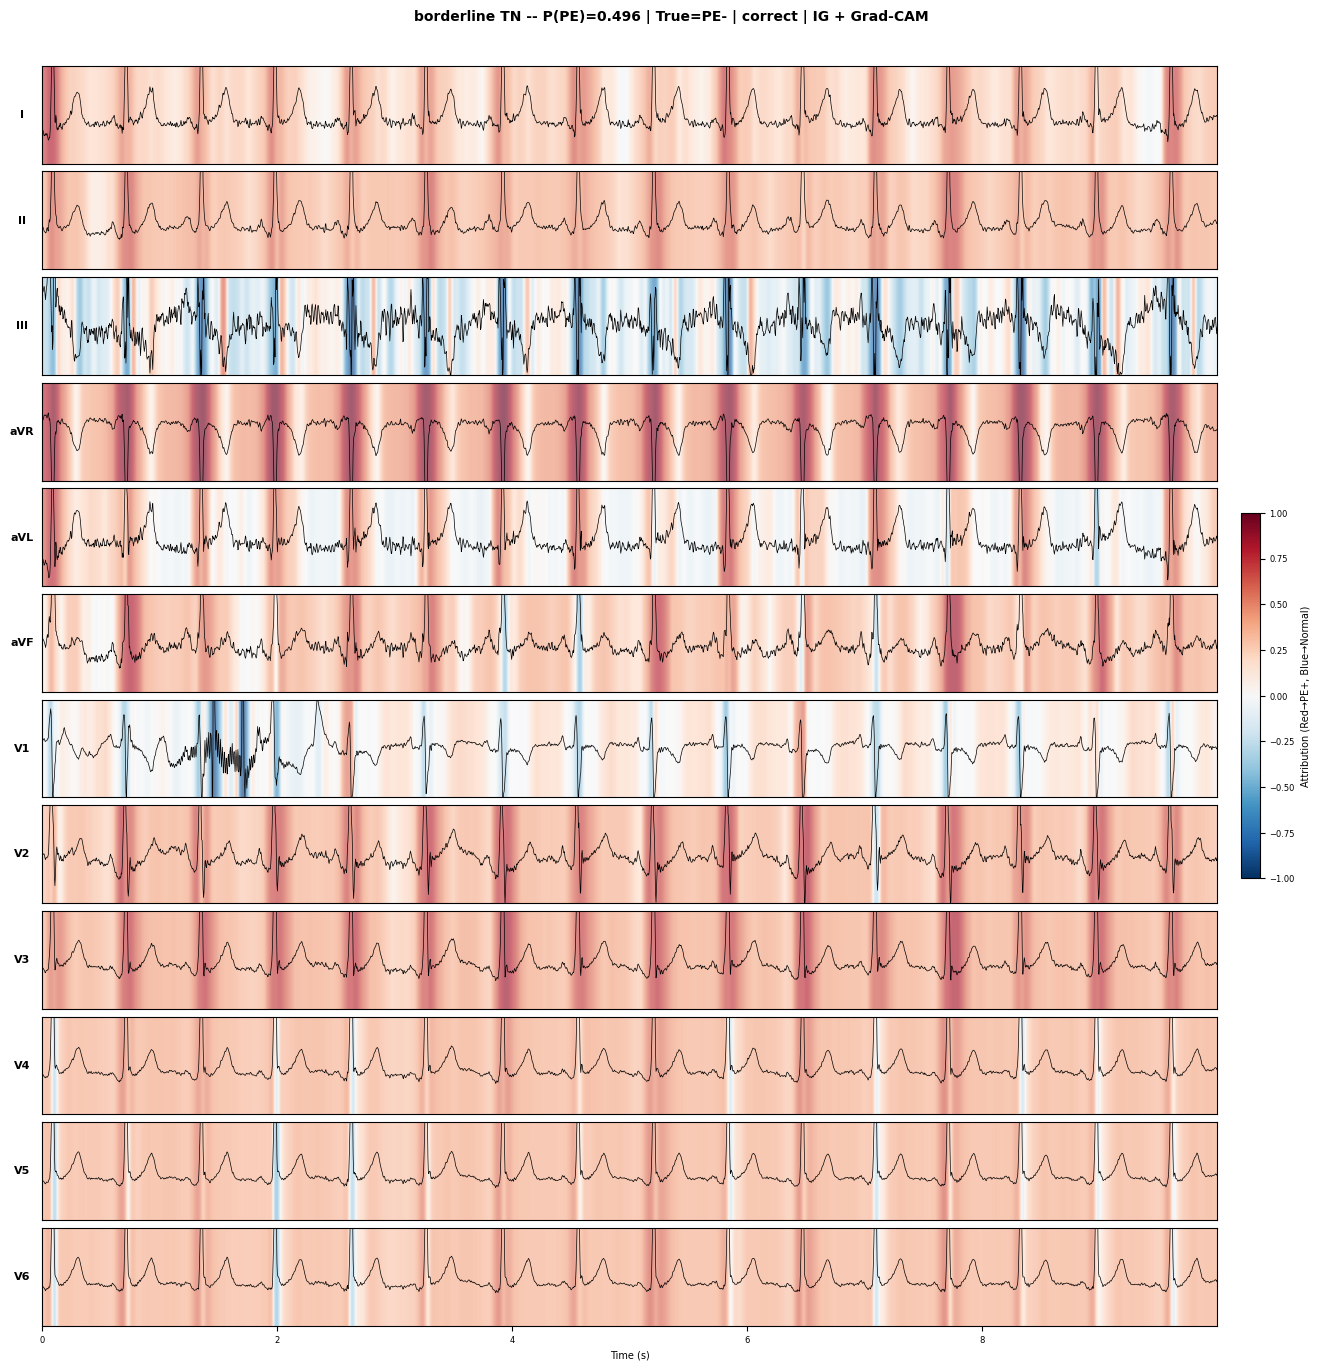


Computing saliency for borderline_FP (idx=99)...


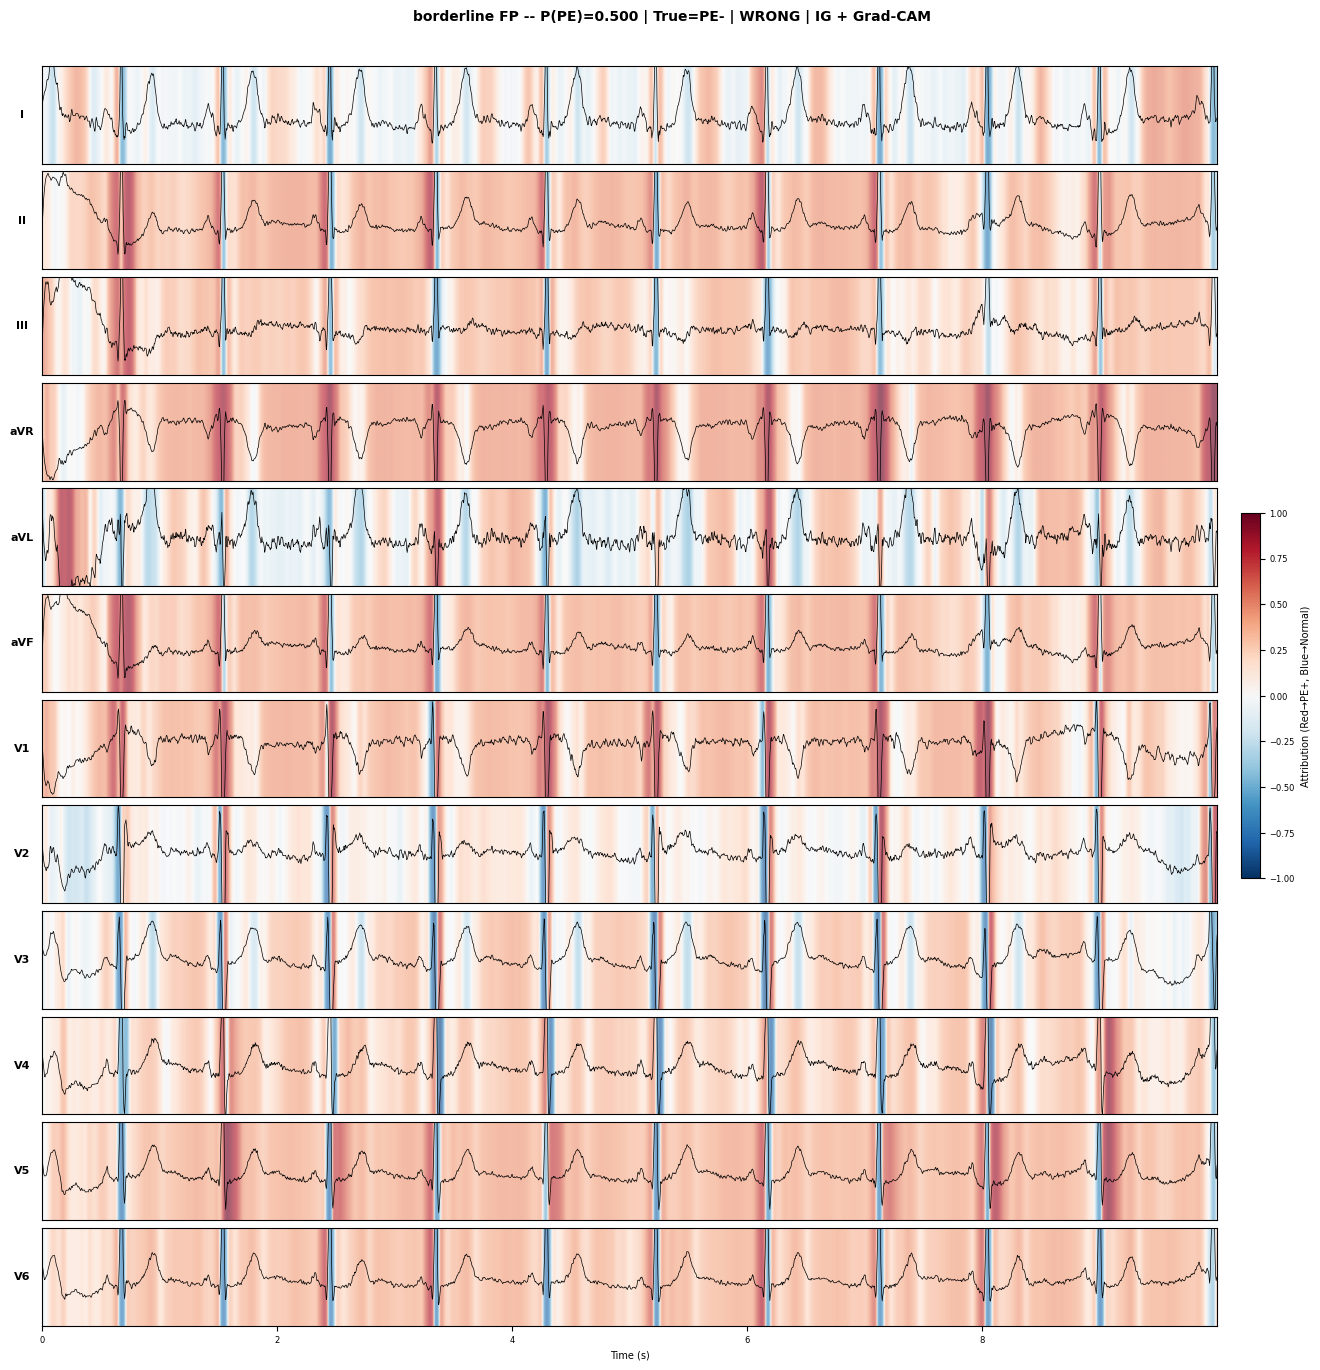


Computing saliency for borderline_FN (idx=410)...


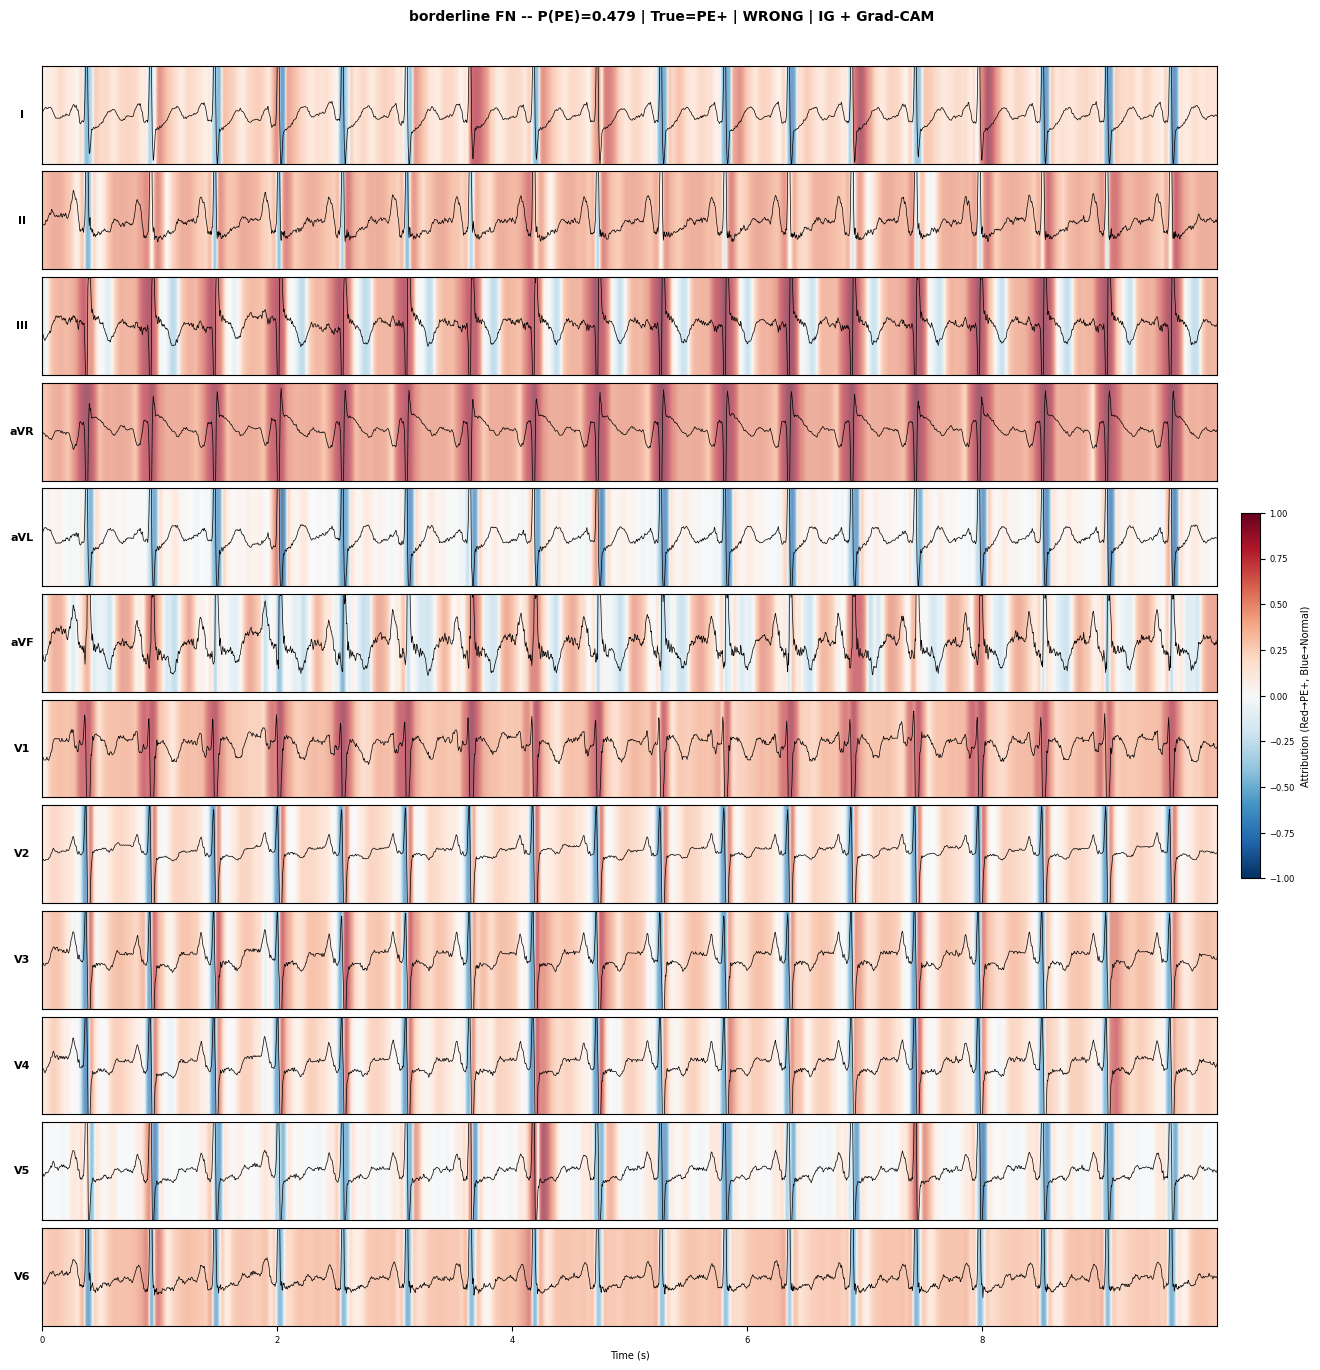

In [31]:
# Compute and plot saliency for all 8 cases
model.eval()
for case_name, idx in cases.items():
    print(f'\nComputing saliency for {case_name} (idx={idx})...')
    attr, ig_raw, gc_raw = combined_saliency(model, X_test[idx])
    label = 'PE+' if y_test[idx] == 1 else 'PE-'
    correct = 'correct' if pred[idx] == int(y_test[idx]) else 'WRONG'
    title = (f'{case_name.replace("_", " ")} -- P(PE)={probs[idx]:.3f} | '
             f'True={label} | {correct} | IG + Grad-CAM')
    plot_saliency_ecg(X_test[idx], attr, probs[idx], title)

### 10b. Class-Averaged Temporal Saliency

Average IG attribution across all PE+ vs PE- test samples to see where the model consistently looks.

In [32]:
# Class-averaged Integrated Gradients across all test samples
print('Computing IG for all test samples (may take a minute)...')
ig_all = []
for i in range(len(X_test)):
    ig_i = integrated_gradients(model, X_test[i], target_class=1, n_steps=32, smooth_sigma=5.0)
    ig_all.append(ig_i)
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(X_test)}')

ig_all = np.array(ig_all)  # (N_test, 12, 2500)
ig_pos = ig_all[y_test == 1].mean(axis=0)  # (12, 2500)
ig_neg = ig_all[y_test == 0].mean(axis=0)  # (12, 2500)
print(f'Done. PE+ samples: {(y_test == 1).sum()}, PE- samples: {(y_test == 0).sum()}')

Computing IG for all test samples (may take a minute)...


  50/436


  100/436


  150/436


  200/436


  250/436


  300/436


  350/436


  400/436


Done. PE+ samples: 67, PE- samples: 369


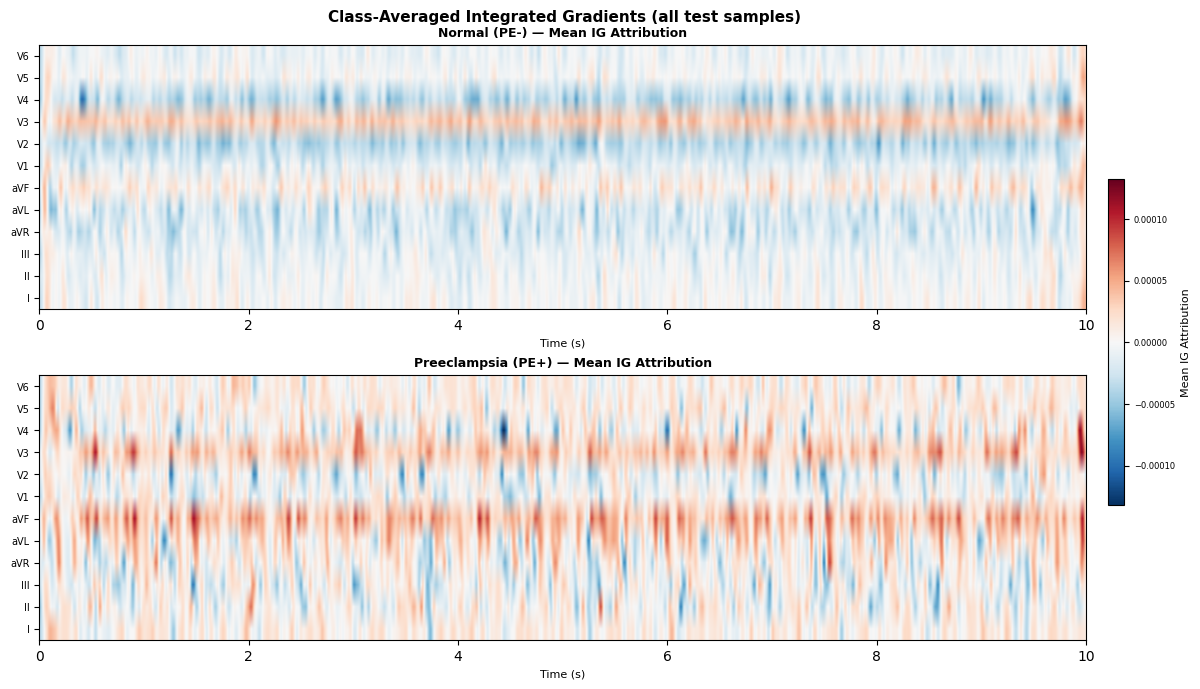

In [33]:
# Class-averaged IG heatmaps side by side
t = np.arange(2500) / 250.0

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                         gridspec_kw={'hspace': 0.25, 'top': 0.93, 'bottom': 0.08})

vmax = max(np.abs(ig_pos).max(), np.abs(ig_neg).max())
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im0 = axes[0].imshow(ig_neg, aspect='auto', cmap='RdBu_r', norm=norm,
                      extent=[0, 10, -0.5, 11.5], interpolation='bilinear')
axes[0].set_yticks(range(12))
axes[0].set_yticklabels(LEAD_NAMES, fontsize=7)
axes[0].set_title('Normal (PE-) — Mean IG Attribution', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Time (s)', fontsize=8)

im1 = axes[1].imshow(ig_pos, aspect='auto', cmap='RdBu_r', norm=norm,
                      extent=[0, 10, -0.5, 11.5], interpolation='bilinear')
axes[1].set_yticks(range(12))
axes[1].set_yticklabels(LEAD_NAMES, fontsize=7)
axes[1].set_title('Preeclampsia (PE+) — Mean IG Attribution', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Time (s)', fontsize=8)

cbar = fig.colorbar(im1, ax=axes, location='right', fraction=0.015, pad=0.02)
cbar.set_label('Mean IG Attribution', fontsize=8)
cbar.ax.tick_params(labelsize=6)

fig.suptitle('Class-Averaged Integrated Gradients (all test samples)', fontsize=11, fontweight='bold')
plt.show()

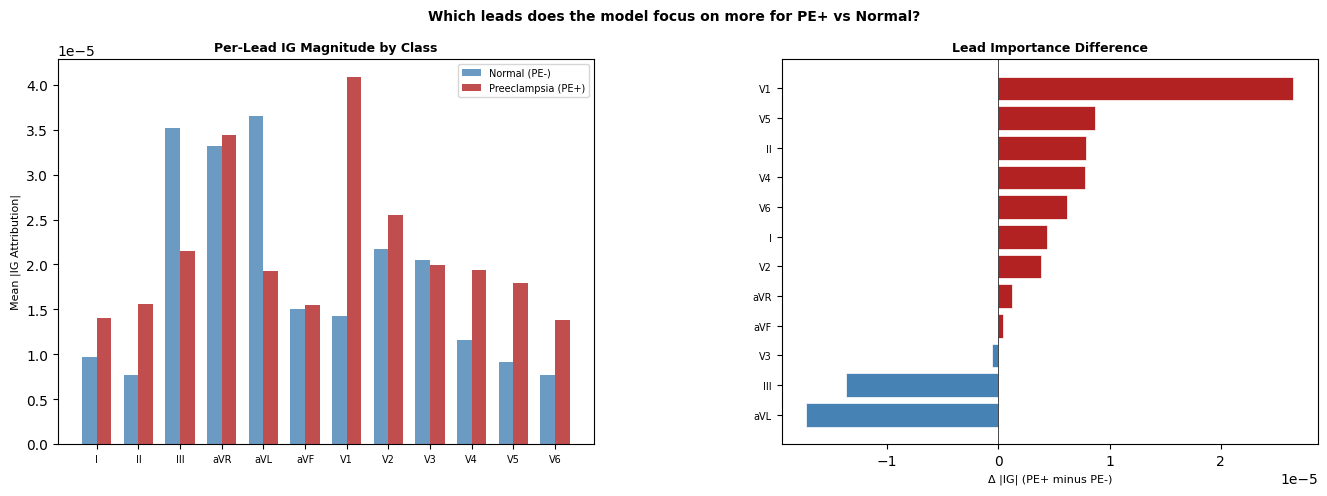

In [34]:
# Per-lead IG magnitude comparison: PE+ vs PE-
lead_ig_pos = np.abs(ig_pos).mean(axis=1)  # (12,)
lead_ig_neg = np.abs(ig_neg).mean(axis=1)  # (12,)
diff = lead_ig_pos - lead_ig_neg

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'wspace': 0.35, 'left': 0.06, 'right': 0.96})

# Per-lead IG by class
x_pos = np.arange(12)
w = 0.35
axes[0].bar(x_pos - w/2, lead_ig_neg, w, label='Normal (PE-)', color='steelblue', alpha=0.8)
axes[0].bar(x_pos + w/2, lead_ig_pos, w, label='Preeclampsia (PE+)', color='firebrick', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(LEAD_NAMES, fontsize=7)
axes[0].set_ylabel('Mean |IG Attribution|', fontsize=8)
axes[0].set_title('Per-Lead IG Magnitude by Class', fontsize=9, fontweight='bold')
axes[0].legend(fontsize=7)

# Difference (PE+ - PE-) sorted
order = np.argsort(diff)
colors = ['firebrick' if d > 0 else 'steelblue' for d in diff[order]]
axes[1].barh(range(12), diff[order], color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(12))
axes[1].set_yticklabels([LEAD_NAMES[i] for i in order], fontsize=7)
axes[1].set_xlabel('Δ |IG| (PE+ minus PE-)', fontsize=8)
axes[1].set_title('Lead Importance Difference', fontsize=9, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.5)

plt.suptitle('Which leads does the model focus on more for PE+ vs Normal?',
             fontsize=10, fontweight='bold')
plt.show()

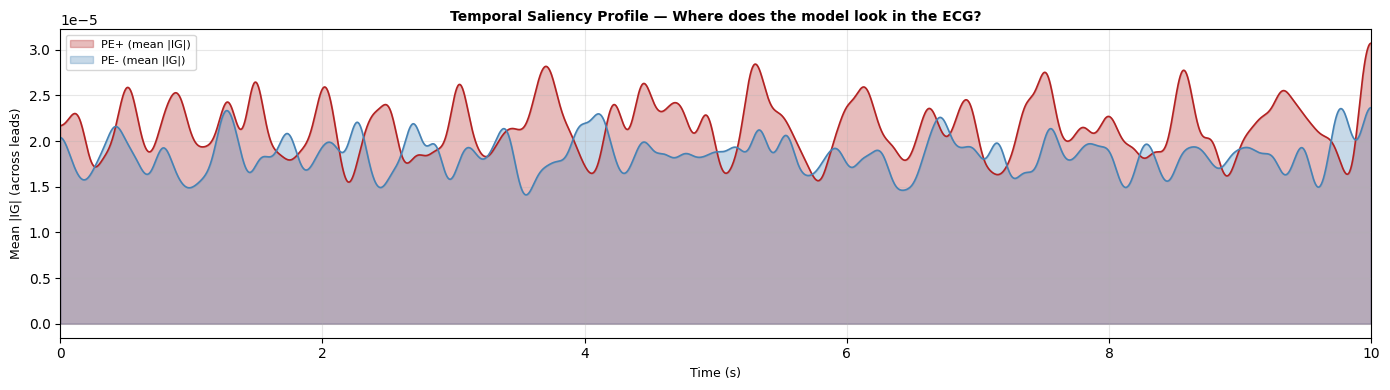

In [35]:
# Temporal saliency profile: aggregate across leads, compare PE+ vs PE- over time
# Shows WHERE in the 10-second window the model focuses (cardiac cycle phase)
temporal_pos = np.abs(ig_pos).mean(axis=0)  # (2500,) - mean across 12 leads
temporal_neg = np.abs(ig_neg).mean(axis=0)

# Smooth for clarity
temporal_pos_s = gaussian_filter1d(temporal_pos, sigma=15)
temporal_neg_s = gaussian_filter1d(temporal_neg, sigma=15)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(t, temporal_pos_s, alpha=0.3, color='firebrick', label='PE+ (mean |IG|)')
ax.fill_between(t, temporal_neg_s, alpha=0.3, color='steelblue', label='PE- (mean |IG|)')
ax.plot(t, temporal_pos_s, color='firebrick', linewidth=1.2)
ax.plot(t, temporal_neg_s, color='steelblue', linewidth=1.2)
ax.set_xlabel('Time (s)', fontsize=9)
ax.set_ylabel('Mean |IG| (across leads)', fontsize=9)
ax.set_title('Temporal Saliency Profile — Where does the model look in the ECG?',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Layer-by-Layer Activation Flow

Traces the confident TP through every layer of the network: input ECG -> 4 stages of (conv -> attention) -> GAP -> lead pool -> classifier. Shows how the raw signal transforms into abstract features at each depth.

In [36]:
TRACK_LEAD = 1   # Lead II
TRACK_IDX = cases['confident_TP']
print(f'Tracking idx={TRACK_IDX}, lead={LEAD_NAMES[TRACK_LEAD]}, P(PE)={probs[TRACK_IDX]:.3f}')

flow_acts = {}
def cap(name):
    def hook(_m, _i, output):
        if isinstance(output, tuple):
            output = output[0]
        flow_acts[name] = output.detach().cpu()
    return hook

handles = [
    model.stage1_conv.register_forward_hook(cap('s1_conv')),
    model.stage1_attn.register_forward_hook(cap('s1_attn')),
]
for i, stage in enumerate(model.later_stages):
    handles.append(stage['conv'].register_forward_hook(cap(f's{i+2}_conv')))
    handles.append(stage['attn'].register_forward_hook(cap(f's{i+2}_attn')))

with torch.no_grad():
    x_in = torch.tensor(X_test[TRACK_IDX:TRACK_IDX+1], dtype=torch.float32).to(DEVICE)
    logits_tr = model(x_in)
    probs_tr = torch.softmax(logits_tr, dim=1)

for h in handles:
    h.remove()

print(f'Logits  = {logits_tr.cpu().numpy().ravel()}')
print(f'Softmax = {probs_tr.cpu().numpy().ravel()}  ->  P(PE)={probs_tr[0,1].item():.4f}')
print('\nActivation shapes:')
for name, t in flow_acts.items():
    print(f'  {name:<10}  {tuple(t.shape)}')

Tracking idx=404, lead=II, P(PE)=0.867
Logits  = [-1.1614131   0.71378493]
Softmax = [0.13294141 0.8670586 ]  ->  P(PE)=0.8671

Activation shapes:
  s1_conv     (1, 12, 16, 1250)
  s1_attn     (1, 12, 16, 1250)
  s2_conv     (1, 12, 32, 625)
  s2_attn     (1, 12, 32, 625)
  s3_conv     (1, 12, 48, 312)
  s3_attn     (1, 12, 48, 312)
  s4_conv     (1, 12, 64, 156)
  s4_attn     (1, 12, 64, 156)


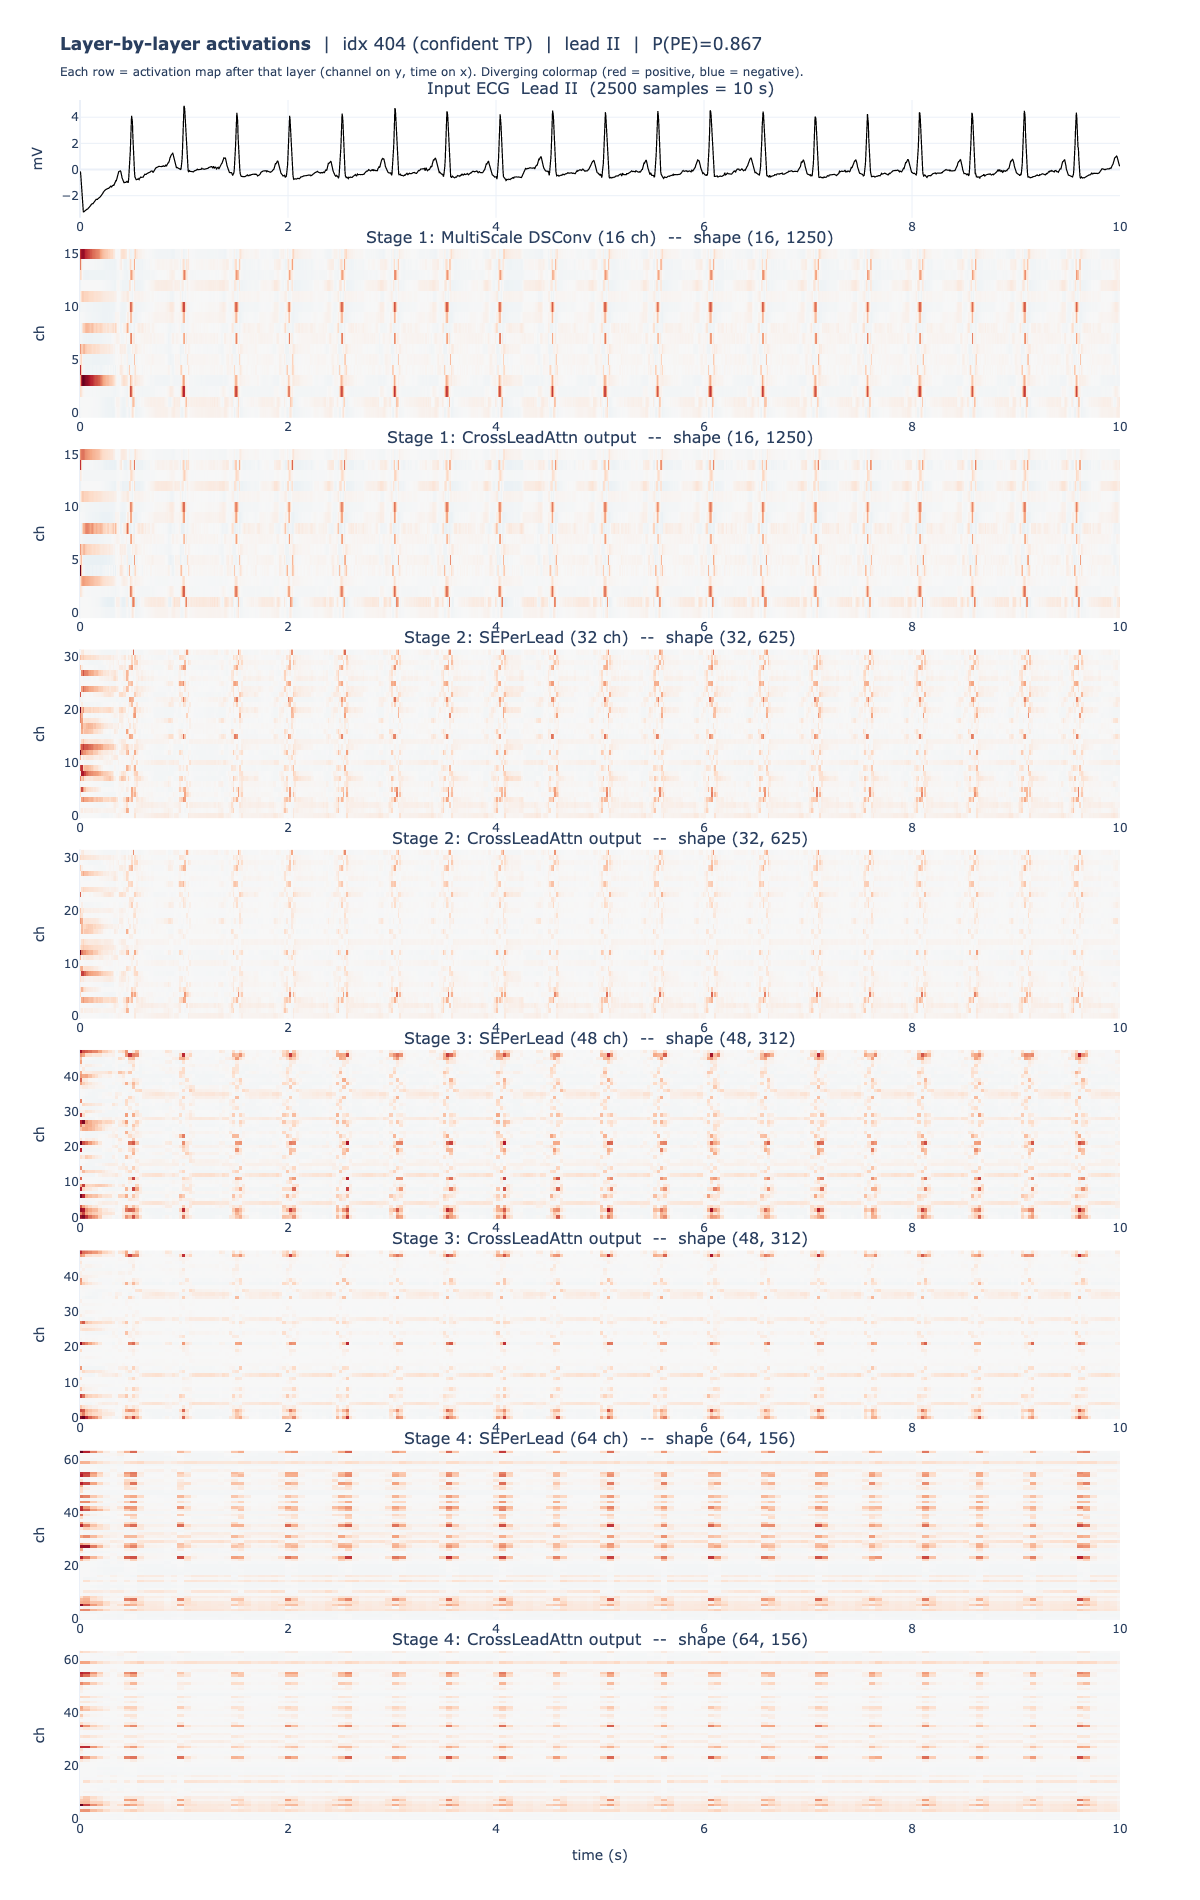

In [37]:
ecg_lead = X_test[TRACK_IDX, TRACK_LEAD, :]
t_input = np.arange(2500) / 250.0

stage_keys = [
    ('Stage 1: MultiScale DSConv (16 ch)', 's1_conv'),
    ('Stage 1: CrossLeadAttn output',      's1_attn'),
    ('Stage 2: SEPerLead (32 ch)',          's2_conv'),
    ('Stage 2: CrossLeadAttn output',       's2_attn'),
    ('Stage 3: SEPerLead (48 ch)',          's3_conv'),
    ('Stage 3: CrossLeadAttn output',       's3_attn'),
    ('Stage 4: SEPerLead (64 ch)',          's4_conv'),
    ('Stage 4: CrossLeadAttn output',       's4_attn'),
]

n_rows = 1 + len(stage_keys)
fig = make_subplots(
    rows=n_rows, cols=1, shared_xaxes=False, vertical_spacing=0.018,
    row_heights=[0.08] + [0.115] * len(stage_keys),
    subplot_titles=[f'Input ECG  Lead {LEAD_NAMES[TRACK_LEAD]}  (2500 samples = 10 s)'] +
                   [f'{name}  --  shape {tuple(flow_acts[k].shape[2:])}' for name, k in stage_keys],
)
fig.add_trace(go.Scatter(x=t_input, y=ecg_lead, mode='lines',
                          line=dict(color='black', width=1.2), showlegend=False), row=1, col=1)

for r, (name, key) in enumerate(stage_keys, start=2):
    a = flow_acts[key][0, TRACK_LEAD].numpy()
    C, T_stage = a.shape
    t_stage = np.linspace(0, 10.0, T_stage)
    cmax = float(np.abs(a).max()) or 1.0
    fig.add_trace(go.Heatmap(
        x=t_stage, y=np.arange(C), z=a,
        colorscale='RdBu_r', zmid=0, zmin=-cmax, zmax=cmax,
        showscale=False,
        hovertemplate='ch=%{y}<br>t=%{x:.2f}s<br>act=%{z:.3f}<extra></extra>',
    ), row=r, col=1)

fig.update_xaxes(range=[0, 10.0])
fig.update_yaxes(title_text='mV', row=1, col=1)
for r in range(2, n_rows + 1):
    fig.update_yaxes(title_text='ch', row=r, col=1)
fig.update_xaxes(title_text='time (s)', row=n_rows, col=1)
fig.update_layout(
    template='plotly_white', width=1200, height=200 * n_rows + 100,
    title=(f'<b>Layer-by-layer activations</b>  |  idx {TRACK_IDX} (confident TP)  |  '
           f'lead {LEAD_NAMES[TRACK_LEAD]}  |  P(PE)={probs[TRACK_IDX]:.3f}<br>'
           f'<sub>Each row = activation map after that layer (channel on y, time on x). '
           f'Diverging colormap (red = positive, blue = negative).</sub>'),
)
fig.show()

## 12. GAP Voting -- Per-Channel Contribution to PE Decision

After lead-attention pooling, the 64-dim vector feeds into `Linear(64->2)`. The per-channel contribution to the PE-vs-Normal margin is: `vote[i] = embedding[i] * (W[PE,i] - W[Normal,i])`.

- `vote[i] > 0` pushes toward PE
- `vote[i] < 0` pushes toward Normal
- Sum of all votes + bias difference = decision margin

Embeddings shape: (436, 64)


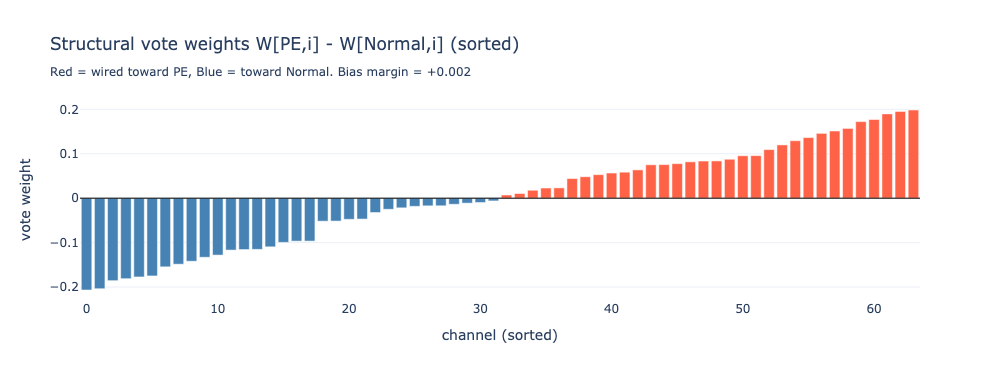

In [38]:
# Extract embeddings for all test samples (post lead-pool, pre-dropout, pre-fc)
embeddings_store = []
def embed_hook(_m, _i, output):
    embeddings_store.append(output.detach().cpu())

h = model.lead_pool.register_forward_hook(embed_hook)
with torch.no_grad():
    batch_size = 64
    for start in range(0, len(X_test), batch_size):
        xb = torch.tensor(X_test[start:start+batch_size], dtype=torch.float32).to(DEVICE)
        _ = model(xb)
h.remove()
all_embeddings = torch.cat(embeddings_store, dim=0).numpy()  # (N_test, 64)
print(f'Embeddings shape: {all_embeddings.shape}')

# Classifier weights
W = model.fc.weight.detach().cpu().numpy()   # (2, 64)
b = model.fc.bias.detach().cpu().numpy()     # (2,)
vote_weights = W[1] - W[0]                  # (64,) positive = PE-wired

# 1. Structural vote weights
sort_idx = np.argsort(vote_weights)
colors_w = ['tomato' if v > 0 else 'steelblue' for v in vote_weights[sort_idx]]

fig = go.Figure(go.Bar(
    x=np.arange(len(vote_weights)), y=vote_weights[sort_idx],
    marker_color=colors_w, showlegend=False,
    hovertemplate='ch=%{customdata}<br>vote weight=%{y:.3f}<extra></extra>',
    customdata=sort_idx,
))
fig.add_hline(y=0, line=dict(color='black', width=1))
fig.update_layout(
    template='plotly_white', width=1000, height=380,
    title=f'Structural vote weights W[PE,i] - W[Normal,i] (sorted)<br>'
          f'<sub>Red = wired toward PE, Blue = toward Normal. Bias margin = {b[1]-b[0]:+.3f}</sub>',
    xaxis_title='channel (sorted)', yaxis_title='vote weight',
)
fig.show()

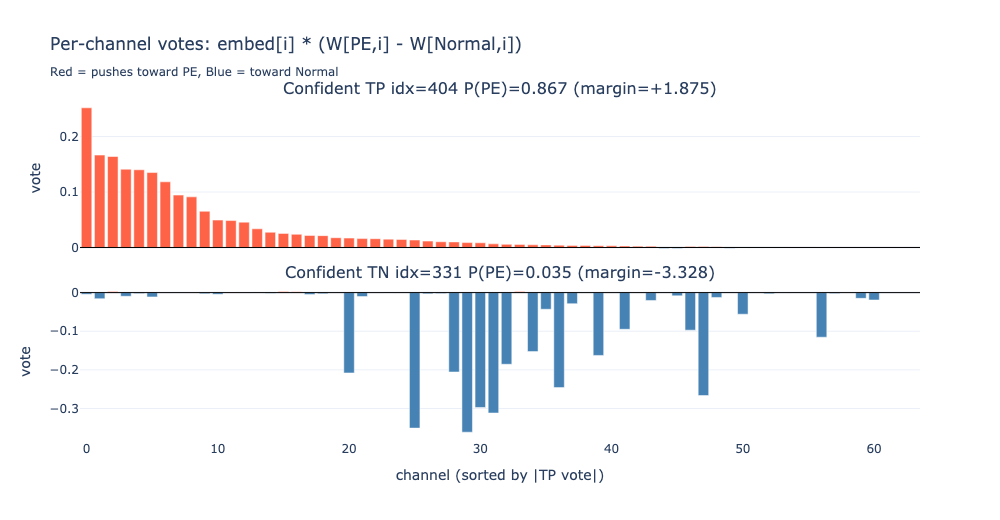

In [39]:
# 2. Per-sample votes: confident TP vs confident TN
tp_idx = cases['confident_TP']
tn_idx = cases['confident_TN']
emb_tp = all_embeddings[tp_idx]
emb_tn = all_embeddings[tn_idx]

votes_tp = emb_tp * vote_weights
votes_tn = emb_tn * vote_weights

sort_abs = np.argsort(-np.abs(votes_tp))

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=(
        f'Confident TP idx={tp_idx} P(PE)={probs[tp_idx]:.3f} (margin={votes_tp.sum()+b[1]-b[0]:+.3f})',
        f'Confident TN idx={tn_idx} P(PE)={probs[tn_idx]:.3f} (margin={votes_tn.sum()+b[1]-b[0]:+.3f})',
    ))
for row, (votes, label) in enumerate([(votes_tp, 'TP'), (votes_tn, 'TN')], start=1):
    fig.add_trace(go.Bar(
        x=np.arange(len(votes)), y=votes[sort_abs],
        marker_color=['tomato' if v > 0 else 'steelblue' for v in votes[sort_abs]],
        showlegend=False,
        hovertemplate='ch=%{customdata}<br>vote=%{y:.4f}<extra></extra>',
        customdata=sort_abs,
    ), row=row, col=1)
    fig.add_hline(y=0, line=dict(color='black', width=1), row=row, col=1)
    fig.update_yaxes(title_text='vote', row=row, col=1)
fig.update_xaxes(title_text='channel (sorted by |TP vote|)', row=2, col=1)
fig.update_layout(template='plotly_white', width=1000, height=520,
    title='Per-channel votes: embed[i] * (W[PE,i] - W[Normal,i])<br>'
          '<sub>Red = pushes toward PE, Blue = toward Normal</sub>')
fig.show()

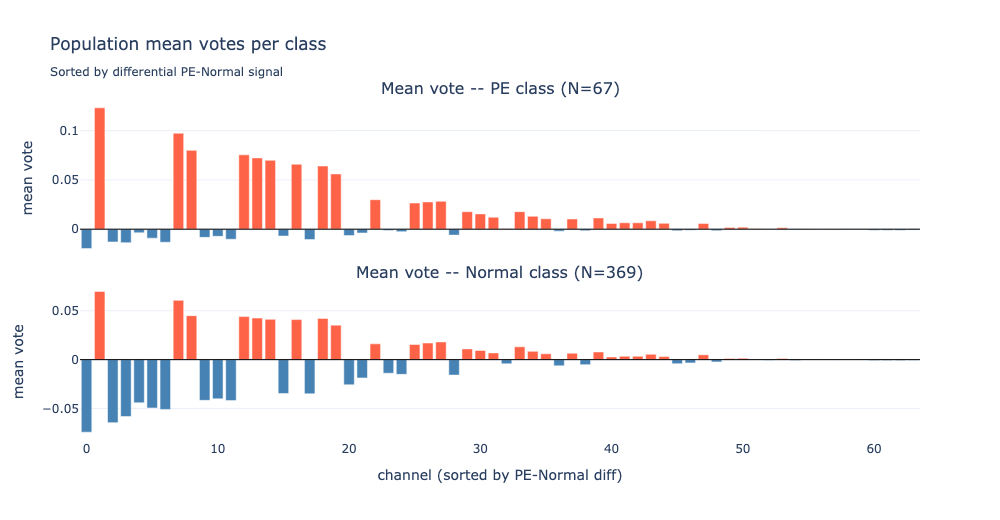

Bias margin b[PE]-b[Normal] = +0.0021
Mean total margin -- PE samples:     +0.8238
Mean total margin -- Normal samples: -0.0684


In [40]:
# 3. Population-level mean votes by class
all_votes = all_embeddings * vote_weights[None, :]  # (N_test, 64)
mean_votes_pe = all_votes[y_test == 1].mean(axis=0)
mean_votes_norm = all_votes[y_test == 0].mean(axis=0)

diff_order = np.argsort(-(mean_votes_pe - mean_votes_norm))

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=(
        f'Mean vote -- PE class (N={int(y_test.sum())})',
        f'Mean vote -- Normal class (N={int((y_test==0).sum())})',
    ))
for row, (mv, label) in enumerate([(mean_votes_pe, 'PE'), (mean_votes_norm, 'Normal')], start=1):
    fig.add_trace(go.Bar(
        x=np.arange(len(mv)), y=mv[diff_order],
        marker_color=['tomato' if v > 0 else 'steelblue' for v in mv[diff_order]],
        showlegend=False,
        hovertemplate='ch=%{customdata}<br>mean vote=%{y:.4f}<extra></extra>',
        customdata=diff_order,
    ), row=row, col=1)
    fig.add_hline(y=0, line=dict(color='black', width=1), row=row, col=1)
    fig.update_yaxes(title_text='mean vote', row=row, col=1)
fig.update_xaxes(title_text='channel (sorted by PE-Normal diff)', row=2, col=1)
fig.update_layout(template='plotly_white', width=1000, height=520,
    title='Population mean votes per class<br>'
          '<sub>Sorted by differential PE-Normal signal</sub>')
fig.show()

print(f'Bias margin b[PE]-b[Normal] = {b[1]-b[0]:+.4f}')
print(f'Mean total margin -- PE samples:     {(all_votes[y_test==1].sum(axis=1) + b[1]-b[0]).mean():+.4f}')
print(f'Mean total margin -- Normal samples: {(all_votes[y_test==0].sum(axis=1) + b[1]-b[0]).mean():+.4f}')

## 13. PCA of Learned Embeddings

Projects the 64-dimensional learned representations (post lead-attention pooling) into 2D via PCA. Shows the decision boundary as a filled contour of the linear classifier evaluated on the PCA plane, and reveals how well the model separates PE+ from PE- in its learned feature space.

PCA explained variance: PC1=0.784, PC2=0.093, total=0.876


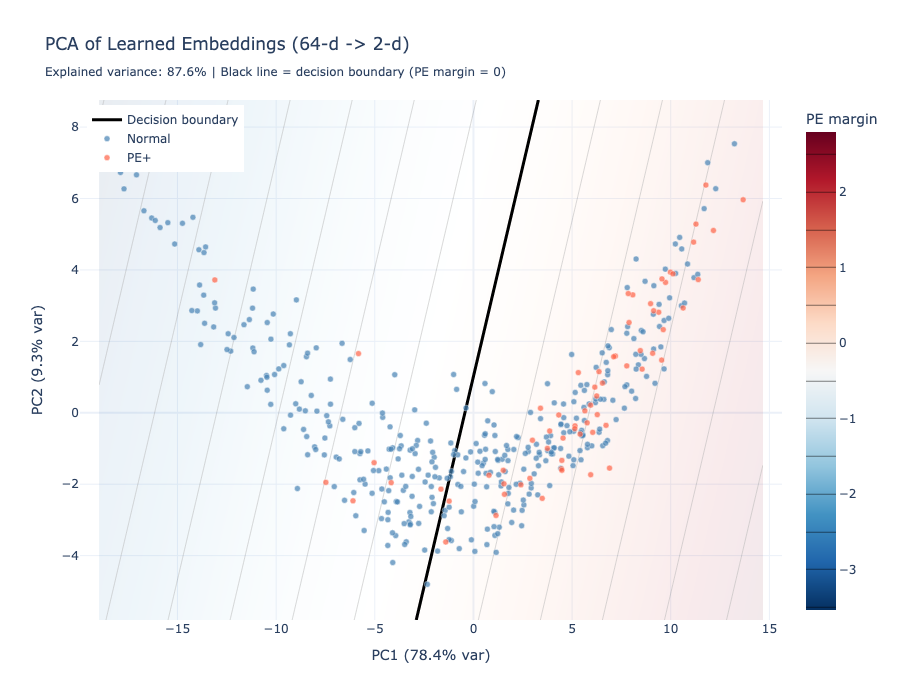

In [41]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
emb_scaled = scaler.fit_transform(all_embeddings)

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_scaled)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, '
      f'PC2={pca.explained_variance_ratio_[1]:.3f}, '
      f'total={pca.explained_variance_ratio_.sum():.3f}')

# Decision boundary: project the linear classifier into PCA space
# logit_PE - logit_Normal = embedding @ vote_weights + (b[1] - b[0])
# In PCA space: pca_coords @ (pca.components_ @ scaler.scale_^(-1)) @ vote_weights + offset
# We compute the decision function on a grid in PCA space

x_min, x_max = emb_pca[:, 0].min() - 1, emb_pca[:, 0].max() + 1
y_min, y_max = emb_pca[:, 1].min() - 1, emb_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_pca = np.c_[xx.ravel(), yy.ravel()]

# Inverse transform: PCA space -> scaled space -> original space -> decision
grid_scaled = pca.inverse_transform(grid_pca)
grid_orig = scaler.inverse_transform(grid_scaled)
decision = grid_orig @ vote_weights + (b[1] - b[0])
decision = decision.reshape(xx.shape)

# Plot
fig = go.Figure()

fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 200),
    y=np.linspace(y_min, y_max, 200),
    z=decision,
    colorscale='RdBu_r', opacity=0.3,
    contours=dict(showlines=True, coloring='heatmap'),
    showscale=True, colorbar=dict(title='PE margin'),
    hoverinfo='skip',
))

fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 200),
    y=np.linspace(y_min, y_max, 200),
    z=decision,
    contours=dict(start=0, end=0, size=0, coloring='none',
                  showlines=True),
    line=dict(color='black', width=3),
    showscale=False,
    hoverinfo='skip',
    name='Decision boundary',
))

for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'PE+')]:
    mask = y_test == label
    fig.add_trace(go.Scatter(
        x=emb_pca[mask, 0], y=emb_pca[mask, 1],
        mode='markers', name=name,
        marker=dict(size=6, color=color, opacity=0.7,
                    line=dict(width=0.5, color='white')),
        hovertemplate=f'{name}<br>PC1=%{{x:.2f}}<br>PC2=%{{y:.2f}}<br>P(PE)=%{{customdata:.3f}}<extra></extra>',
        customdata=probs[mask],
    ))

fig.update_layout(
    title=f'PCA of Learned Embeddings (64-d -> 2-d)<br>'
          f'<sub>Explained variance: {100*pca.explained_variance_ratio_.sum():.1f}% | '
          f'Black line = decision boundary (PE margin = 0)</sub>',
    xaxis_title=f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)',
    yaxis_title=f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)',
    template='plotly_white', width=900, height=700,
    legend=dict(x=0.01, y=0.99),
)
fig.show()

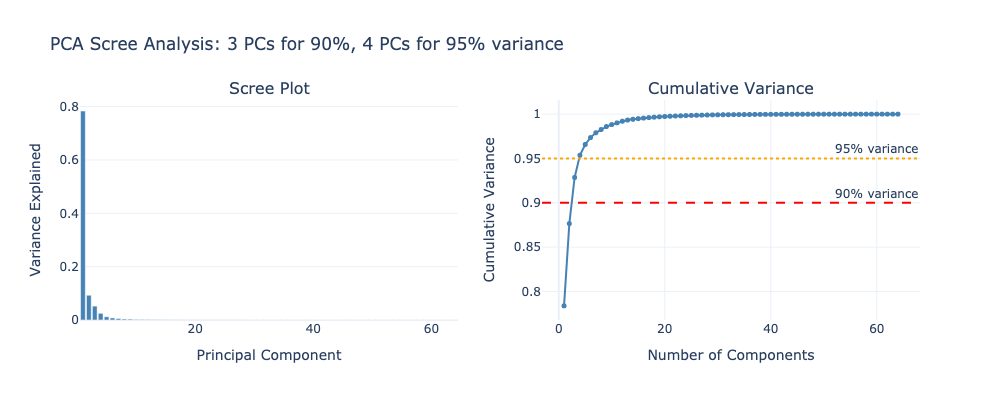

In [42]:
# PCA scree plot: how many components capture meaningful variance?
pca_full = PCA().fit(emb_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig = make_subplots(rows=1, cols=2, subplot_titles=['Scree Plot', 'Cumulative Variance'])

fig.add_trace(go.Bar(
    x=list(range(1, len(pca_full.explained_variance_ratio_) + 1)),
    y=pca_full.explained_variance_ratio_,
    marker_color='steelblue', showlegend=False,
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=list(range(1, len(cumvar) + 1)), y=cumvar,
    mode='lines+markers', marker=dict(size=5, color='steelblue'),
    showlegend=False,
), row=1, col=2)
fig.add_hline(y=0.90, line_dash='dash', line_color='red',
              annotation_text='90% variance', row=1, col=2)
fig.add_hline(y=0.95, line_dash='dot', line_color='orange',
              annotation_text='95% variance', row=1, col=2)

n_90 = int(np.searchsorted(cumvar, 0.90)) + 1
n_95 = int(np.searchsorted(cumvar, 0.95)) + 1
fig.update_layout(
    title=f'PCA Scree Analysis: {n_90} PCs for 90%, {n_95} PCs for 95% variance',
    template='plotly_white', width=1000, height=400,
)
fig.update_xaxes(title_text='Principal Component', row=1, col=1)
fig.update_yaxes(title_text='Variance Explained', row=1, col=1)
fig.update_xaxes(title_text='Number of Components', row=1, col=2)
fig.update_yaxes(title_text='Cumulative Variance', row=1, col=2)
fig.show()

## 14. t-SNE of Learned Embeddings

t-SNE preserves local neighborhood structure better than PCA, revealing clusters and separation patterns in the 64-dimensional embedding space. We run multiple perplexity values to check robustness of the structure.

The decision boundary from the linear classifier is approximated by computing the PE margin for each point in t-SNE space (via k-NN interpolation from the actual embeddings).

t-SNE done. KL divergence: 0.4840


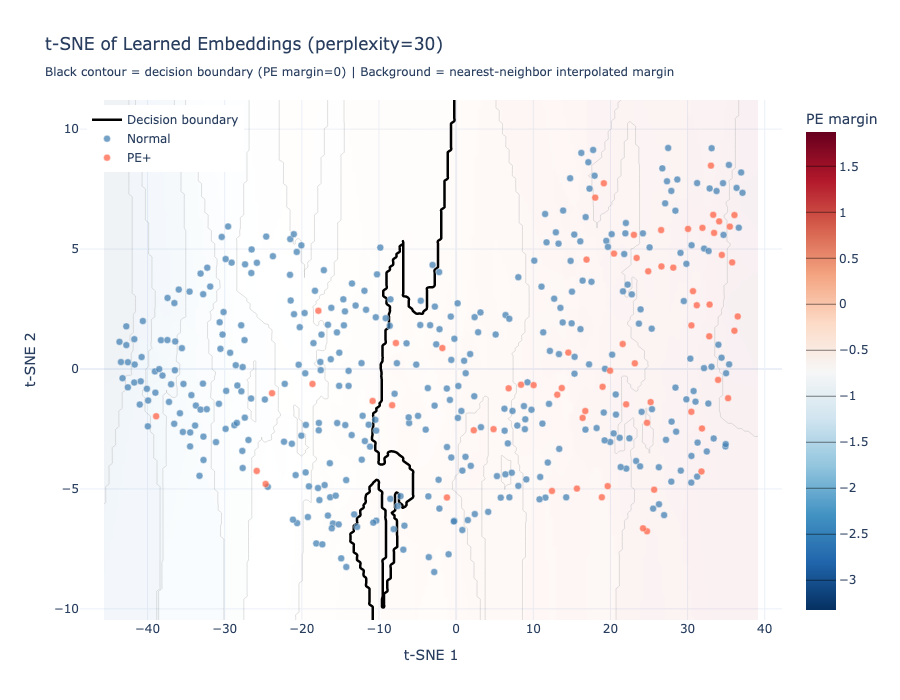

In [43]:
from sklearn.manifold import TSNE
from scipy.interpolate import griddata

# Compute the actual decision margin for each test sample
margins = all_embeddings @ vote_weights + (b[1] - b[0])  # positive = PE side

# Run t-SNE at perplexity=30 (standard)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', max_iter=1000)
emb_tsne = tsne.fit_transform(emb_scaled)
print(f't-SNE done. KL divergence: {tsne.kl_divergence_:.4f}')

# Interpolate decision margin onto a grid in t-SNE space
x_min, x_max = emb_tsne[:, 0].min() - 2, emb_tsne[:, 0].max() + 2
y_min, y_max = emb_tsne[:, 1].min() - 2, emb_tsne[:, 1].max() + 2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Use nearest-neighbor interpolation of the PE margin
margin_grid = griddata(emb_tsne, margins, grid_points, method='nearest')
margin_grid = margin_grid.reshape(xx.shape)

fig = go.Figure()

# Decision margin contour
fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 200),
    y=np.linspace(y_min, y_max, 200),
    z=margin_grid,
    colorscale='RdBu_r', opacity=0.25,
    contours=dict(showlines=False, coloring='heatmap'),
    showscale=True, colorbar=dict(title='PE margin'),
    hoverinfo='skip',
))

# Decision boundary (margin=0)
fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 200),
    y=np.linspace(y_min, y_max, 200),
    z=margin_grid,
    contours=dict(start=0, end=0, size=0, coloring='none', showlines=True),
    line=dict(color='black', width=2.5),
    showscale=False, hoverinfo='skip',
    name='Decision boundary',
))

# Scatter points
for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'PE+')]:
    mask = y_test == label
    fig.add_trace(go.Scatter(
        x=emb_tsne[mask, 0], y=emb_tsne[mask, 1],
        mode='markers', name=name,
        marker=dict(size=7, color=color, opacity=0.75,
                    line=dict(width=0.5, color='white')),
        hovertemplate=(f'{name}<br>t-SNE1=%{{x:.1f}}<br>t-SNE2=%{{y:.1f}}<br>'
                       f'P(PE)=%{{customdata[0]:.3f}}<br>margin=%{{customdata[1]:.3f}}<extra></extra>'),
        customdata=np.column_stack([probs[mask], margins[mask]]),
    ))

fig.update_layout(
    title=f't-SNE of Learned Embeddings (perplexity=30)<br>'
          f'<sub>Black contour = decision boundary (PE margin=0) | '
          f'Background = nearest-neighbor interpolated margin</sub>',
    xaxis_title='t-SNE 1', yaxis_title='t-SNE 2',
    template='plotly_white', width=900, height=700,
    legend=dict(x=0.01, y=0.99),
)
fig.show()

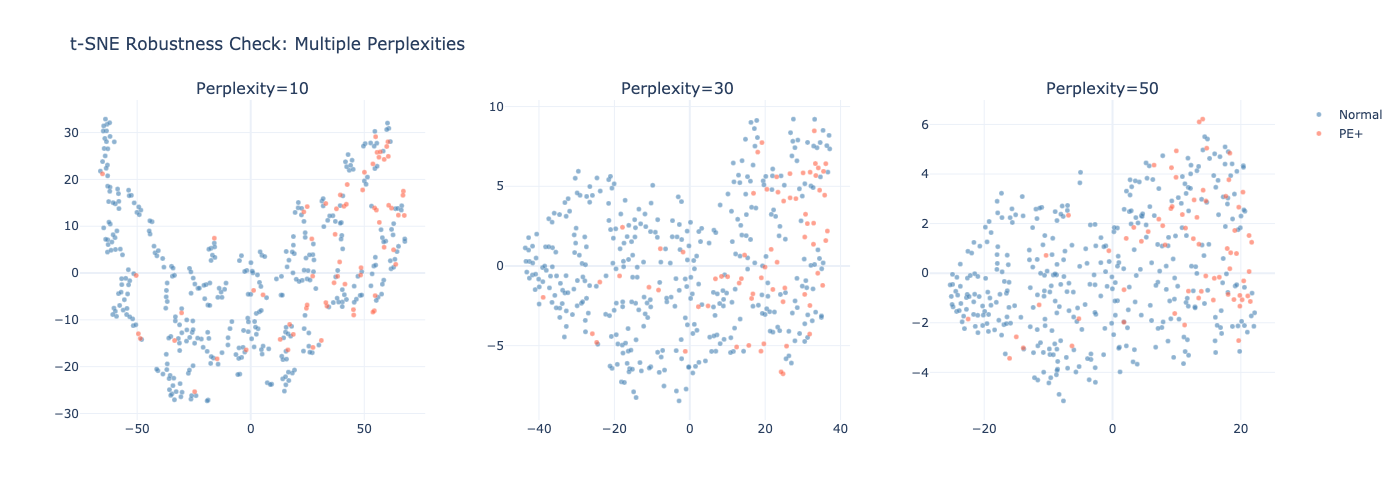

In [44]:
# t-SNE at multiple perplexities to check robustness
fig = make_subplots(rows=1, cols=3, subplot_titles=['Perplexity=10', 'Perplexity=30', 'Perplexity=50'])

for col, perp in enumerate([10, 30, 50], start=1):
    if perp == 30:
        emb_p = emb_tsne  # reuse
    else:
        tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', max_iter=1000)
        emb_p = tsne_p.fit_transform(emb_scaled)
    
    for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'PE+')]:
        mask = y_test == label
        fig.add_trace(go.Scatter(
            x=emb_p[mask, 0], y=emb_p[mask, 1],
            mode='markers', name=name,
            marker=dict(size=5, color=color, opacity=0.6,
                        line=dict(width=0.3, color='white')),
            showlegend=(col == 1),
        ), row=1, col=col)

fig.update_layout(
    title='t-SNE Robustness Check: Multiple Perplexities',
    template='plotly_white', width=1400, height=500,
)
fig.show()

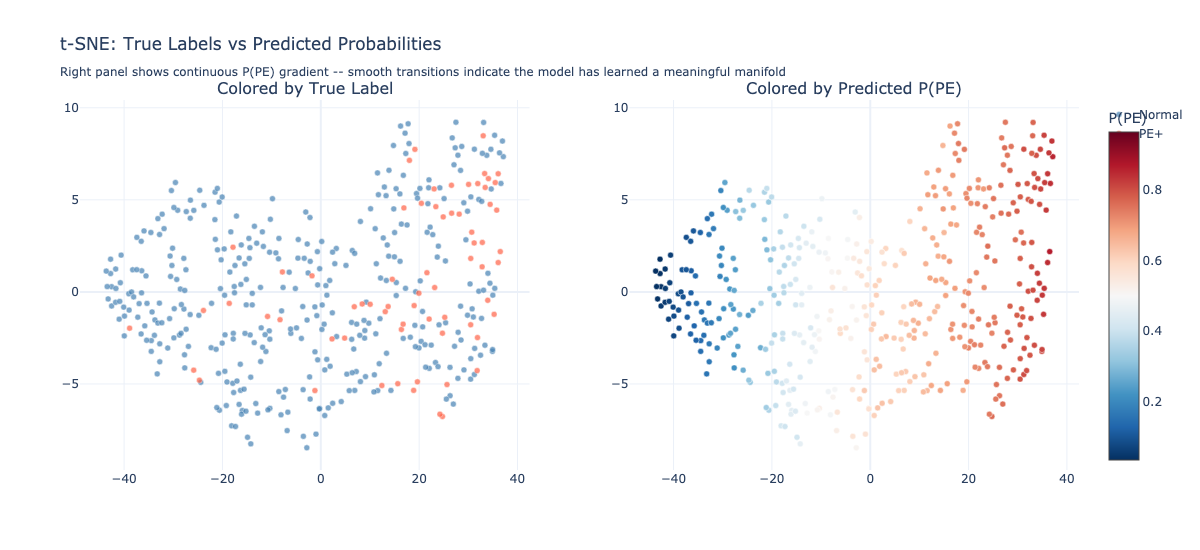

In [45]:
# t-SNE colored by predicted probability (continuous gradient)
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Colored by True Label', 'Colored by Predicted P(PE)'])

# Left: true label
for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'PE+')]:
    mask = y_test == label
    fig.add_trace(go.Scatter(
        x=emb_tsne[mask, 0], y=emb_tsne[mask, 1],
        mode='markers', name=name,
        marker=dict(size=6, color=color, opacity=0.7,
                    line=dict(width=0.5, color='white')),
    ), row=1, col=1)

# Right: predicted probability
fig.add_trace(go.Scatter(
    x=emb_tsne[:, 0], y=emb_tsne[:, 1],
    mode='markers', name='P(PE)',
    marker=dict(size=6, color=probs, colorscale='RdBu_r', cmid=0.5,
                showscale=True, colorbar=dict(title='P(PE)', x=1.02),
                line=dict(width=0.5, color='white')),
    showlegend=False,
    hovertemplate='P(PE)=%{marker.color:.3f}<extra></extra>',
), row=1, col=2)

fig.update_layout(
    title='t-SNE: True Labels vs Predicted Probabilities<br>'
          '<sub>Right panel shows continuous P(PE) gradient -- smooth transitions indicate '
          'the model has learned a meaningful manifold</sub>',
    template='plotly_white', width=1200, height=550,
)
fig.show()

## 15. Embedding Space: Misclassification Analysis

Highlights misclassified samples in the embedding space to reveal whether errors cluster together (systematic failure modes) or are scattered (random noise).

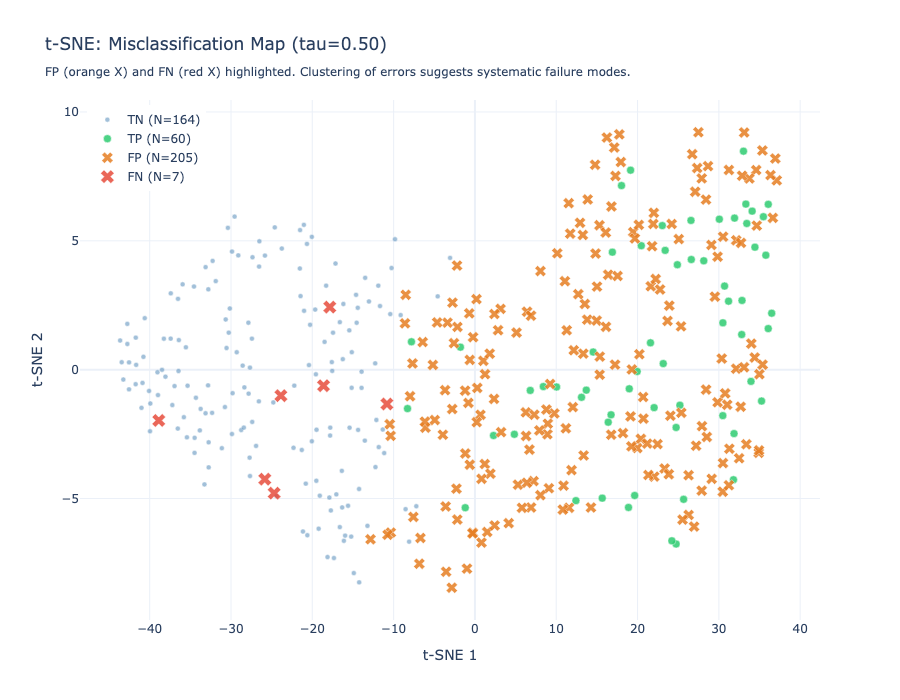

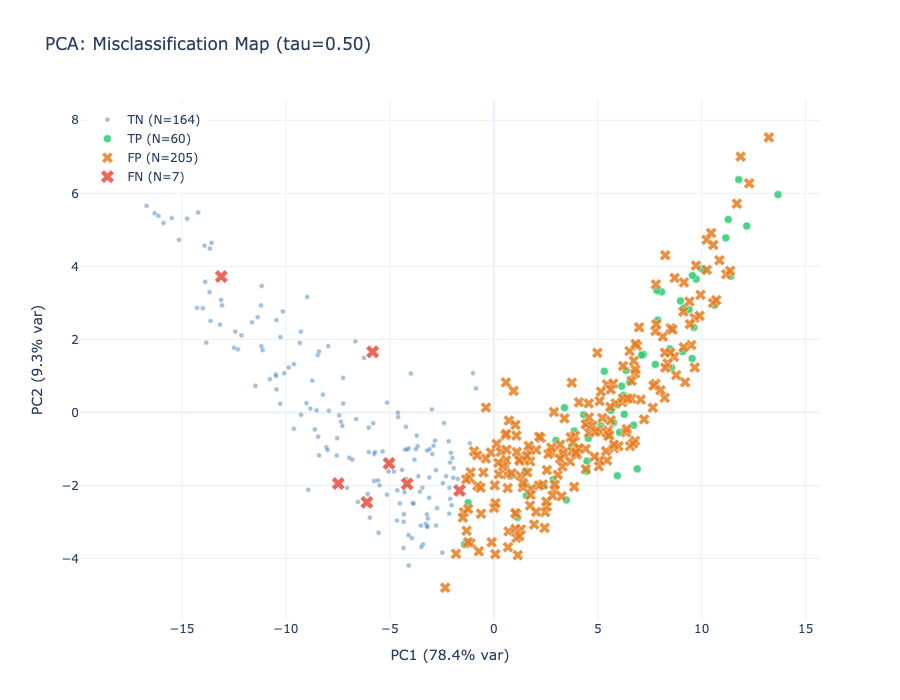

In [46]:
# t-SNE colored by classification outcome (TP/TN/FP/FN)
outcome = np.full(len(y_test), '', dtype=object)
outcome[(y_test == 0) & (pred == 0)] = 'TN'
outcome[(y_test == 0) & (pred == 1)] = 'FP'
outcome[(y_test == 1) & (pred == 0)] = 'FN'
outcome[(y_test == 1) & (pred == 1)] = 'TP'

colors_map = {'TP': '#2ecc71', 'TN': 'steelblue', 'FP': '#e67e22', 'FN': '#e74c3c'}
size_map   = {'TP': 8, 'TN': 5, 'FP': 10, 'FN': 12}

fig = go.Figure()

# Plot in order: TN first (background), then TP, FP, FN on top
for cat in ['TN', 'TP', 'FP', 'FN']:
    mask = outcome == cat
    count = mask.sum()
    fig.add_trace(go.Scatter(
        x=emb_tsne[mask, 0], y=emb_tsne[mask, 1],
        mode='markers', name=f'{cat} (N={count})',
        marker=dict(size=size_map[cat], color=colors_map[cat],
                    opacity=0.5 if cat == 'TN' else 0.85,
                    line=dict(width=0.5, color='white'),
                    symbol='circle' if cat in ('TP', 'TN') else 'x'),
        hovertemplate=f'{cat}<br>P(PE)=%{{customdata:.3f}}<extra></extra>',
        customdata=probs[mask],
    ))

fig.update_layout(
    title=f't-SNE: Misclassification Map (tau=0.50)<br>'
          f'<sub>FP (orange X) and FN (red X) highlighted. '
          f'Clustering of errors suggests systematic failure modes.</sub>',
    xaxis_title='t-SNE 1', yaxis_title='t-SNE 2',
    template='plotly_white', width=900, height=700,
    legend=dict(x=0.01, y=0.99),
)
fig.show()

# Also show in PCA space
fig2 = go.Figure()
for cat in ['TN', 'TP', 'FP', 'FN']:
    mask = outcome == cat
    count = mask.sum()
    fig2.add_trace(go.Scatter(
        x=emb_pca[mask, 0], y=emb_pca[mask, 1],
        mode='markers', name=f'{cat} (N={count})',
        marker=dict(size=size_map[cat], color=colors_map[cat],
                    opacity=0.5 if cat == 'TN' else 0.85,
                    line=dict(width=0.5, color='white'),
                    symbol='circle' if cat in ('TP', 'TN') else 'x'),
        hovertemplate=f'{cat}<br>P(PE)=%{{customdata:.3f}}<extra></extra>',
        customdata=probs[mask],
    ))

fig2.update_layout(
    title='PCA: Misclassification Map (tau=0.50)',
    xaxis_title=f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)',
    yaxis_title=f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)',
    template='plotly_white', width=900, height=700,
    legend=dict(x=0.01, y=0.99),
)
fig2.show()